# BÁO CÁO PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA) HÀNH VI TƯƠNG TÁC AGENT TRÊN FACEBOOK
## ĐỐI SÁNH NHÓM CAN THIỆP PERSONA (INTERVENTION) VS NHÓM ĐỐI CHỨNG TRUNG TÍNH (NEUTRAL CONTROL)

---

# 1: XÁC ĐỊNH MỤC TIÊU VÀ CÂU HỎI NGHIÊN CỨU (RESEARCH QUESTIONS & HYPOTHESES)

## 1.1. Mục tiêu tổng quát
- **Mục tiêu cốt lõi:** Đánh giá tính chân thực (Persona Fidelity), tính nhất quán nhận thức (Cognitive Consistency), và khả năng tự kiểm soát hành vi (Self-Regulation & Spatial Navigation) của mô hình ngôn ngữ lớn (LLM) khi được nạp hồ sơ người dùng (Persona) duyệt mạng xã hội Facebook, đặt trong mối tương quan đối sánh với nhóm đối chứng không có Persona (Neutral Control).

## 1.2. Danh sách 4 Câu hỏi cụ thể 

| Mã RQ | Tên Câu hỏi | Mục tiêu trả lời của EDA |
| :--- | :--- | :--- |
| **RQ1** | **Persona có định hướng hành vi tìm kiếm của Agent hay không?** | Kiểm tra xem việc cung cấp hồ sơ Persona có làm thay đổi cách Agent lựa chọn hành động (`intent`, `tool`) và loại nội dung quan tâm (`target_candidate`: bài viết, nhóm, trang) so với Agent không có Persona hay không. |
| **RQ2** | **Persona có ảnh hưởng nhất quán đến cách Agent tương tác với giao diện hay không?** | Đánh giá xem các đặc điểm hành vi trong Persona (ví dụ: tốc độ nhanh/chậm, đọc lướt/đọc kỹ) có được phản ánh thành các thao tác chuột thực tế như tốc độ cuộn, quãng đường cuộn và thời gian thao tác hay không. |
| **RQ3** | **Persona có giúp Agent duy trì mục tiêu khi gặp nội dung gây phân tán hay không?** | Phân tích khả năng Agent giữ sự tập trung vào sở thích được thiết lập ban đầu khi xuất hiện các nội dung hấp dẫn trên Feed, thông qua số bước khám phá, tỷ lệ bằng chứng thu thập đúng mục tiêu (`explored_evidence_share`) và các cảnh báo kiểm soát hành vi. |
| **RQ4** | **Agent có sử dụng ký ức dài hạn và tự điều chỉnh phiên làm việc hay không?** | Kiểm tra khả năng Agent ghi nhớ sở thích qua nhiều phiên (`Cross-session Memory Queries`), tránh lặp lại hành vi cũ và điều chỉnh thời lượng hoạt động theo ngân sách thời gian đã đặt trước (`planned_session_minutes`). |

## 1.3. Danh sách Giả thuyết Kỳ vọng Trước Thực nghiệm (Prior Hypotheses: $H_1 \rightarrow H_4$)

Việc xác lập giả thuyết trước khi phân tích dữ liệu giúp định hình rõ kỳ vọng và tránh việc suy diễn theo cảm tính:

1. **Giả thuyết $H_1$ (Về định hướng tìm kiếm nội dung):**
   - *Kỳ vọng:* Agent có Persona sẽ chủ động tìm kiếm và chọn đọc các bài viết, nhóm, trang (`target_candidate`) đúng với sở thích được thiết lập (như Thiền, Cờ vua, Thể hình, Triết học) với tỷ lệ trên **85%**. Ngược lại, Agent không có Persona sẽ chỉ bấm ngẫu nhiên hoặc lướt qua các bài viết xuất hiện sẵn trên Bảng tin mà không có chủ đích rõ ràng.

2. **Giả thuyết $H_2$ (Về thao tác cuộn chuột và nhịp độ tương tác):**
   - *Kỳ vọng:* Thao tác cuộn chuột và nhịp độ bấm của Agent sẽ phản ánh đúng tính cách đã cài đặt trong Persona:
     - Nhóm có nhãn đọc nhanh (`pace = quick`): cuộn nhanh và dứt khoát hơn (thời gian cuộn dưới $200\text{ ms}$, quãng cuộn dài trên $800\text{ px}$).
     - Nhóm có nhãn đọc kỹ hoặc cân bằng (`pace = slow/balanced`): cuộn chậm rãi và cẩn thận hơn (thời gian cuộn trên $240\text{ ms}$, quãng cuộn ngắn dưới $500\text{ px}$).
     - Nhóm không có Persona: cuộn đều đều theo cấu hình mặc định của trình duyệt tự động, không thay đổi linh hoạt theo thói quen đọc.

3. **Giả thuyết $H_3$ (Về khả năng tập trung và tránh bị phân tâm):**
   - *Kỳ vọng:* Agent có Persona sẽ giữ vững mục tiêu ban đầu, không bị sa đà vào các nội dung ngoài lề trên Bảng tin (`situational_steps = 0`) và không bị hệ thống nhắc nhở (`CẢNH BÁO TIẾT CHẾ`). Ngược lại, Agent không có Persona dễ bị cuốn theo các bài viết ngẫu nhiên (sa đà liên tiếp $\ge 5$ bước) và sẽ bị kích hoạt cảnh báo nhắc nhở nhiều lần.

4. **Giả thuyết $H_4$ (Về sử dụng ký ức dài hạn và quản lý thời gian):**
   - *Kỳ vọng:* Agent có Persona sẽ nhớ và tìm kiếm tiếp các từ khóa từ phiên trước (`recent_queries_from_memory`) trong ít nhất 20 bước đầu, đồng thời biết tự giảm dần hoạt động và chủ động dừng phiên khi thời gian làm việc sắp hết (`remaining_seconds` về gần 0). Ngược lại, Agent không có Persona không dùng lại ký ức cũ và chỉ dừng lại khi bị hết giờ bắt buộc (Timeout) hoặc gặp lỗi kẹt giao diện.

In [10]:
# Khởi tạo môi trường, import các thư viện cốt lõi và nạp Loader
import sys
from pathlib import Path

# Đảm bảo project root và thư mục algorithms, viz có trong sys.path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị pandas
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Import PersonaActionLoader chuẩn từ loaders
from loaders.loaders.persona_action import PersonaActionLoader

loader = PersonaActionLoader()
print("[✓] Đã khởi tạo PersonaActionLoader thành công!")
print(f"[✓] Thư mục gốc project: {project_root}")
print(f"[✓] Thư mục lưu bảng (CSV): {project_root / 'output' / 'tables'}")
print(f"[✓] Thư mục lưu biểu đồ (PNG): {project_root / 'output' / 'figures'}")

[✓] Đã khởi tạo PersonaActionLoader thành công!
[✓] Thư mục gốc project: d:\source_code\eda_persona
[✓] Thư mục lưu bảng (CSV): d:\source_code\eda_persona\output\tables
[✓] Thư mục lưu biểu đồ (PNG): d:\source_code\eda_persona\output\figures


# 2: BỐI CẢNH VÀ NGUỒN GỐC DỮ LIỆU

## 2.1. Bối cảnh Sinh Dữ liệu & Thiết kế Thực nghiệm

- **Tác nhân sinh dữ liệu:**
  - Dữ liệu được sinh ra từ các **Tác tử Trí tuệ Nhân tạo Tự trị** xây dựng trên nền tảng **DeepSeek Harness** (mô hình GLM 5.3 Flash).
  - Tác tử điều khiển trình duyệt qua Playwright, kết nối Chromium bằng CDP. Tích hợp lớp cloak/stealth để giảm dấu hiệu automation. Lớp hành vi mô phỏng người dùng: smooth_wheel cuộn theo gia tốc với delta/delay ngẫu nhiên; native_click chọn tọa độ ngẫu nhiên trong vùng hiển thị hợp lệ của phần tử, dùng CDP Input.dispatchMouseEvent và mô phỏng hover/mouse move.

- **Môi trường & Đặc tính Tài khoản:**
  - Tác tử thao tác trực tiếp trên giao diện web desktop của Facebook (`https://www.facebook.com`).
  - Toàn bộ các phiên chạy được thực hiện trên **tài khoản Facebook mới tạo hoàn toàn (Tài khoản trắng - Cold start)**: không có bạn bè, không có lịch sử like/share, không follow trang/nhóm nào trước đó.
  - **Ý nghĩa cốt lõi:** Việc sử dụng tài khoản trắng loại bỏ hoàn toàn **Thiên lệch Thuật toán Đề xuất của Meta**. Bảng tin ban đầu là trung tính tuyệt đối; mọi sự phân hóa trong hành vi duyệt bài, từ khóa tìm kiếm hay nội dung tương tác đều phản ánh thuần túy sự điều hướng của hồ sơ Persona (hoặc tính ngẫu nhiên của nhóm đối chứng).

- **Khoảng thời gian thu thập & Quy mô:**
  - Dữ liệu thu thập ngày **30/09/2026**.
  - Thiết kế A/B đối sánh: **6 phiên can thiệp có Persona** đối sánh với **2 phiên đối chứng không có Persona**.

## 2.2. Chu trình Hoạt động của Agent (Agent Loop Lifecycle & Data Generation)

Toàn bộ dữ liệu dùng cho phân tích EDA được sinh ra từ chu trình vòng lặp tác tử tự trị (**Agent Loop**) qua 3 tầng kiến trúc cốt lõi:

![Kiến trúc Chu trình Vòng lặp Agent](output/figures/agent_loop.png)

### Ba Tầng Hoạt động trong Chu trình Sinh Dữ liệu:

1. **Tầng Quản lý & Khởi tạo Môi trường (Management Layer):**
   - **Đầu vào:** Ghép cặp hồ sơ người dùng (`Persona`) với tài khoản Facebook trắng hoàn toàn (`Fresh Accounts`) nhằm triệt tiêu thuật toán gợi ý của Meta.
   - **Trích xuất & Lập lịch:** Hệ thống chuẩn bị đặc trưng nền tảng Facebook (`Platform-Specific Feature Extraction`) và thiết lập ngân sách thời gian phiên chạy (`Activity Scheduler`).

2. **Tầng Thực thi & Vòng lặp Nhận thức - Hành động (Execution Layer - Agent Loop):**
   Vòng lặp diễn ra liên tục theo chu trình 4 pha tại mỗi bước tuần tự ($S_t \rightarrow A_t$):
   - **Observe (Quan sát):** Quét tín hiệu DOM từ màn hình chính (`Main screen`), bảng tin, bài viết trên viewport và thông báo (`Notifications`).
   - **Decide (Ra quyết định):** Tác tử gửi ngữ cảnh qua `LLM Gateway` (DeepSeek Harness) kết hợp cùng `Bot Memory Processing` (bộ nhớ làm việc ngắn hạn `working_memory` và ký ức phiên trước `long-term`) để lựa chọn ý định (`intent`), công cụ (`tool`), đối tượng mục tiêu (`target_candidate`) và viện dẫn chiều tâm lý (`dimension_evidence`).
   - **Act & Humanize (Thực thi cơ học):** Lệnh được chuyển qua trình duyệt ẩn danh `Cloakbrowser (stealth chromium)` và mô phỏng cử chỉ tự nhiên của con người (`Humanize actionability`: cuộn chuột mượt `smooth_wheel`, ngắt nhịp thời gian `gesture_ms`, tốc độ `pace`, click ngẫu nhiên tọa độ).
   - **Feedback & State Update:** Nhận kết quả xác minh DOM (`verified`), cập nhật thời gian trôi qua, nạp lại bộ nhớ và quay lại pha *Observe*.

3. **Tầng Lưu trữ & Cung cấp Dữ liệu EDA (Storage Layer):**
   - Mọi biến cố trong vòng lặp được ghi nhận tự động vào Activity Logs để tiến hành EDA.

## 2.3. Cấu trúc Phân cấp 4 Tầng & Đơn vị Phân tích (Multi-level Data Hierarchy)

```
Episode (N = 8) ---[1:N]---> Step (N = 437, Base Unit)
                               ├---[1:N]---> Browser Gesture (N = 189 actions, 63 gestures)
                               └---[1:N]---> Cognitive Evidence (N = 546 evidences)
```

### Ma trận Đặc tính 4 Cấp độ Dữ liệu:

| Cấp độ | Quy mô ($N$) | Ý nghĩa Phân tích | Đại lượng Đo lường Chính |
| :--- | :---: | :--- | :--- |
| **1. Episode** | **8** phiên | Quan sát vĩ mô toàn phiên (~10–12 phút) | Tổng thời lượng, tổng số bước, số bề mặt ghé thăm, lý do dừng |
| **2. Step** | **437** bước | **Đơn vị phân tích cơ sở (Base Unit)**: Quyết định $S_t \rightarrow A_t$ | `intent`, `tool`, `surface`, `reaction`, `verified`, `latency_ratio` |
| **3. Gesture** | **189** actions | Thao tác cơ học vật lý trên trình duyệt | `gesture_pace`, `gesture_ms`, `gesture_total_px`, `execution_mode` |
| **4. Evidence** | **546** items | Viện dẫn nhận thức & chiều tâm lý của Persona | `dimension`, `role` (primary/secondary), `weight`, `ref_id` |


[✓] Đã lưu biểu đồ cấu trúc dữ liệu tại: d:\source_code\eda_persona\output\figures\step2_data_hierarchy.png


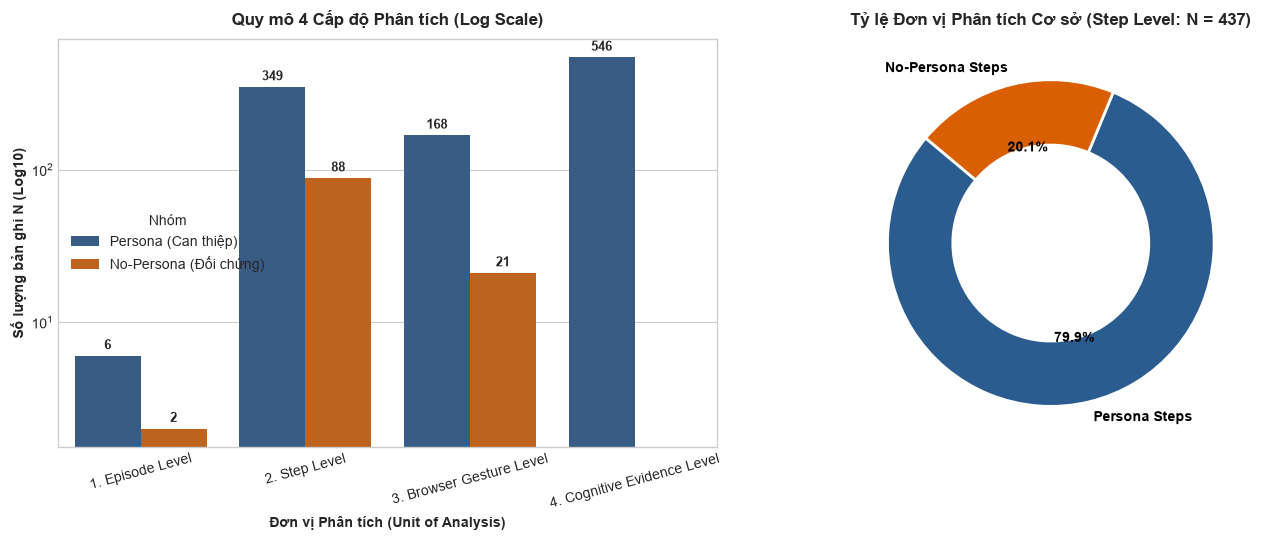

[✓] BẢNG TỔNG HỢP CẤU TRÚC ĐA CẤP (UNITS OF ANALYSIS):


,Cấp độ phân tích (Unit of Analysis),Tổng số bản ghi (N),Nhóm Persona,Nhóm No-Persona,Khóa chính (PK),Khóa ngoại (FK),Toàn vẹn tham chiếu
0,1. Episode Level (Phiên),8,6,2,episode_id,None,100% Valid
1,2. Step Level (Bước),437,349,88,"(episode_id, step_index)",episode_id -> Episode.PK,100% Valid
2,3. Browser Gesture Level (Cử chỉ),189,168,21,"(episode_id, step_index, action_order)","(episode_id, step_index) -> Step.PK",100% Valid
3,4. Cognitive Evidence Level (Bằng chứng),546,546,0,"(episode_id, step_index, evidence_order)","(episode_id, step_index) -> Step.PK",100% Valid


In [11]:
# Thực thi kiểm định cấu trúc phân cấp và kiểm tra toàn vẹn khóa ngoại (Referential Integrity)
from algorithms.data_lineage_inspector import inspect_multilevel_structure
from viz.data_lineage_viz import plot_data_hierarchy_distribution

# Nạp đầy đủ 4 cấp độ từ PersonaActionLoader
df_episodes = loader.load_action_logs()
df_steps = loader.load_step_records()
df_actions = loader.load_recent_actions()
df_evidences = loader.load_dimension_evidences()

# Kiểm tra toàn vẹn tham chiếu
lineage_audit = inspect_multilevel_structure(df_episodes, df_steps, df_actions, df_evidences)
df_hierarchy_summary = lineage_audit["summary_table"]

# Lưu bảng ra output/tables/
table_path = project_root / "output" / "tables" / "step2_data_hierarchy.csv"
df_hierarchy_summary.to_csv(table_path, index=False, encoding="utf-8-sig")

# Vẽ biểu đồ phân bổ cấu trúc và lưu ra output/figures/
fig_path = project_root / "output" / "figures" / "step2_data_hierarchy.png"
fig = plot_data_hierarchy_distribution(df_hierarchy_summary, fig_path)
plt.show()

print("[✓] BẢNG TỔNG HỢP CẤU TRÚC ĐA CẤP (UNITS OF ANALYSIS):")
display(df_hierarchy_summary)

## 2.4. Data Dictionary

Trong `loaders/persona_action.py`, dữ liệu từ log thô được bóc tách và làm phẳng thành **94 trường phân tích** ở cấp độ bước (`Step Level` — đơn vị phân tích cơ sở). Toàn bộ 94 trường này được tổ chức thành **11 nhóm chức năng logic**:

| STT | Nhóm Chức năng (Functional Group) | Số lượng Trường | Các biến tiêu biểu |
| :---: | :--- | :---: | :--- |
| **1** | **Metadata & Persona Attributes** | 8 | `episode_id`, `persona_id`, `persona_pace`, `persona_rest_style`, `dataset_type`, `step_index`, `timestamp` |
| **2** | **Action Space & Execution Core** | 14 | `tool`, `resolved_tool`, `intent`, `reaction`, `surface`, `verified`, `reason`, `action_summary_verb` |
| **3** | **Latency & Computational Effort** | 5 | `model_latency_ms`, `tool_execution_ms`, `total_step_latency_ms`, `cognitive_latency_ratio` |
| **4** | **Target Candidate (Content Selection)** | 4 | `has_target_candidate`, `target_candidate_kind`, `target_candidate_text`, `target_candidate_url` |
| **5** | **Cognitive Reasoning Matrix** | 14 | `dim_evidence_primary_dimension`, `dim_evidence_max_weight`, `num_dim_primary`, `num_dim_supporting` |
| **6** | **Session Context: Temporal Dynamics** | 6 | `context_elapsed_seconds`, `context_remaining_seconds`, `context_is_overtime`, `context_action_velocity` |
| **7** | **Session Context: Rest & Fatigue** | 2 | `context_rest_accumulated_seconds`, `context_rest_count` |
| **8** | **Session Context: Search & Memory** | 7 | `context_queries_this_session`, `context_recent_queries_from_memory`, `search_rule`, `planner_rule` |
| **9** | **Session Context: Physical Gestures** | 12 | `recent_last_gesture_pace`, `recent_last_gesture_px`, `recent_last_gesture_ms`, `landing_correction` |
| **10** | **Working Memory: Threads & Anti-Drift** | 16 | `wm_current_thread_origin`, `wm_situational_steps`, `wm_has_novelty_warning`, `wm_novelty_guidance` |
| **11** | **Working Memory: Session Summaries** | 6 | `wm_summary_run_minutes`, `wm_summary_planned_minutes`, `wm_summary_read_posts` |
| **TỔNG** | **Toàn bộ Không gian Biến số Cấp Step** | **94** | *Bao quát trọn vẹn chu trình Nhận thức $\rightarrow$ Quyết định $\rightarrow$ Thực thi vật lý* |


In [12]:
# Nạp và hiển thị Data Dictionary từ file chuẩn output/tables/data_dictionary.csv
dict_path = project_root / "output" / "tables" / "data_dictionary.csv"
df_data_dict = pd.read_csv(dict_path)

print(f"[✓] Tổng số trường then chốt trong Data Dictionary: {len(df_data_dict)} trường.")
print("[✓] Phân bổ theo 7 nhóm chính:")
print(df_data_dict["Group"].value_counts().sort_index())

# Hiển thị toàn bộ từ điển dữ liệu với định dạng bảng chi tiết
df_data_dict.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'font-size': '12px'
}).set_table_styles([
    dict(selector='th', props=[('font-weight', 'bold'), ('background-color', '#f0f2f5'), ('text-align', 'center')])
])

[✓] Tổng số trường then chốt trong Data Dictionary: 94 trường.
[✓] Phân bổ theo 7 nhóm chính:
Group
1. Metadata & Persona             8
10. Working Memory & Drift       16
11. WM Session Summaries          6
2. Action Space & Execution      14
3. Latency & Effort               5
4. Target Candidate (Content)     4
5. Cognitive Matrix              14
6. Temporal Budget & Dynamics     6
7. Rest & Fatigue                 2
8. Search & Memory                7
9. Browser Physical Gestures     12
Name: count, dtype: int64


,Group,Field,Type,Meaning,Role,Valid_Values
0,1. Metadata & Persona,dataset_type,category,Nhãn phân loại nhóm thực nghiệm A/B,Independent / Condition Variable,"'persona', 'no_persona'"
1,1. Metadata & Persona,episode_id,string (UUID),Mã định danh duy nhất của từng phiên chạy (Episode),"Primary Key (Episode), Foreign Key (Step)",UUIDv4
2,1. Metadata & Persona,file_name,string,Tên file JSON log thô nguồn,Provenance Attribute,benchmark_eda_*.json
3,1. Metadata & Persona,persona_id,string / null,Mã định danh hồ sơ Persona áp dụng trong phiên,Condition / Foreign Key,vn_000019..87; null (ở nhóm đối chứng)
4,1. Metadata & Persona,persona_pace,string / null,Thuộc tính tốc độ hành vi trong hồ sơ Persona,Independent Variable,"'quick', 'balanced', 'slow'; null"
5,1. Metadata & Persona,persona_rest_style,string / null,Thuộc tính phong cách dừng nghỉ trong hồ sơ Persona,Independent Variable,"'frequent', 'balanced', 'deep'; null"
6,1. Metadata & Persona,step_index,integer,Chỉ số thứ tự bước hành động tuần tự trong phiên,Sequence Index (1-based),1 đến 64
7,1. Metadata & Persona,timestamp,datetime (ISO 8601),Thời điểm ghi nhận hành động trên máy chủ (UTC),Time Attribute,Chuỗi ISO UTC
8,10. Working Memory & Drift,has_working_memory,boolean,Đánh dấu bước này có cấu trúc working_memory hợp lệ,Working Memory Flag,"True, False"
9,10. Working Memory & Drift,wm_cumulative_opened,integer,Số trang/nhóm đã mở tích luỹ trong Working Memory,WM Cumulative Opened,0 đến 15


## 2.5. Tiền Xử lý (Preprocessing) & Kiểm soát Rủi ro Thiên lệch

### A. Quy trình tiền xử lý:
1. **Bóc tách cấu trúc lồng nhau (Unnesting & Flattening):**
   - Trích xuất `target_candidate` (kind, text, url) từ cấu trúc dictionary lồng trong `step_records`.
   - Bóc tách mảng `dimension_evidence` thành bảng quan hệ 1-N (546 bản ghi) và trích xuất chiều chính (`primary`) cùng trọng số cao nhất (`max_weight`) lên cấp độ bước.
2. **Trích xuất thuộc tính bằng Regular Expression:**
   - Sử dụng regex phân tích trường text `recent_actions[].summary` để thu nhận chính xác các tham số vật lý: `total=(\d+)px`, `gesture_ms=(\d+)`, `pace=(fast|careful)`, `mode=(\w+)`.
3. **Chuẩn hóa biến thời gian & ngân sách:**
   - Chuyển đổi timestamp ISO 8601 sang UTC datetime.
   - Tính toán `cognitive_latency_ratio = model_ms / (model_ms + tool_ms)`.

### B. Kiểm soát các Rủi ro Thiên lệch:
| Tên Thiên lệch / Rủi ro | Nguồn gốc | Tác động tiềm ẩn | Biện pháp Kiểm soát & Xử lý trong EDA |
| :--- | :--- | :--- | :--- |
| **Mất cân bằng Cỡ mẫu (Sample Asymmetry)** | 6 phiên Persona ($N=349$) vs 2 phiên No-Persona ($N=88$) | So sánh tổng số lượng tuyệt đối sẽ bị sai lệch hoàn toàn. | **Luôn chuẩn hóa theo tỷ lệ phần trăm (Proportions)**, tỷ lệ per-step, và áp dụng kiểm định phi tham số (Mann-Whitney U, Bootstrap, Permutation tests). |
| **Khuyết thiếu Chọn lọc (Selective Missingness - MAR)** | Một số trường chỉ tồn tại theo ngữ cảnh (ví dụ: `dim_evidence` chỉ có ở nhóm Persona; `gesture_ms` chỉ có khi cuộn chuột). | Dễ bị nhầm lẫn là dữ liệu bị mất (MCAR) và tự ý xóa bỏ dòng. | Xử lý khuyết thiếu theo điều kiện nghiệp vụ: không xóa dòng, phân tích trên tập con hợp lệ (ví dụ: chỉ đo tốc độ cuộn trên các bước cuộn chuột). |
| **Thiên lệch Thời lượng (Duration / Survival Bias)** | Các phiên dừng vì các lý do khác nhau (`completed`, `overtime_threshold_exceeded`). | Bước cuối của phiên có thể có hành vi vội vã hoặc kết thúc đột ngột. | Kiểm soát biến `context_is_overtime` và phân tích riêng biệt các bước trong thời hạn vs các bước quá giờ. |

# 3: KIỂM TRA TỔNG QUAN VÀ CHẤT LƯỢNG DỮ LIỆU

Mục tiêu của phần 3 là thực hiện kiểm tra toàn diện về độ tin cậy của tập dữ liệu hành vi tác tử, bao gồm: kiểm tra trùng lặp, giá trị bất hợp lệ, phân loại khuyết thiếu (MCAR/MAR/MNAR), giải thích điểm ngoại lai (Outliers) và kiểm tra tính liên tục của chuỗi thời gian, xác định quyết định xử lý dữ liệu.

## 3.1. Đánh giá Tổng quan Dữ liệu
- **Kích thước & Dung lượng:** 437 dòng (bước hành động) và 94 cột phân tích.
- **Tính toàn vẹn khóa:** Khóa chính `(episode_id, step_index)` không có bản ghi trùng lặp nào (0 dòng duplicate PK).
- **Giá trị bất hợp lệ:** 0 cột có số âm phi lý; không có timestamp tương lai; các chuỗi rỗng đã được chuẩn hóa.

In [13]:
from algorithms.data_quality_profiler import profile_data_hygiene

hygiene_audit = profile_data_hygiene(df_steps, primary_key=["episode_id", "step_index"])
df_hygiene_summary = hygiene_audit["summary_table"]

# Lưu bảng ra output/tables/
df_hygiene_summary.to_csv(project_root / "output" / "tables" / "step3_quality_summary.csv", index=False, encoding="utf-8-sig")

print("[✓] BẢNG TỔNG HỢP KIỂM TRA VỆ SINH DỮ LIỆU:")
display(df_hygiene_summary)

[✓] BẢNG TỔNG HỢP KIỂM TRA VỆ SINH DỮ LIỆU:


,Hạng mục kiểm tra,Kết quả thực tế,Tiêu chuẩn kỳ vọng,Trạng thái
0,Tổng số dòng (N_rows),437 dòng,> 400 dòng,Đạt
1,Tổng số cột (N_cols),95 cột,>= 90 cột,Đạt
2,Dung lượng bộ nhớ RAM,2.12 MB,< 50 MB,Tối ưu
3,Trùng lặp dòng hoàn toàn (Exact Duplicates),0 dòng,0 dòng,Đạt
4,Trùng lặp khóa chính (PK Duplicates),0 dòng,0 dòng,Đạt
5,Giá trị âm phi logic (Negative values),0 cột vi phạm,0 cột,Đạt
6,Timestamp tương lai / Lỗi thời gian,0 bản ghi,0 bản ghi,Đạt
7,"Chuỗi rỗng placeholder ẩn ('', N/A, null)",2 cột phát hiện,Đã bóc tách thành NaN,Cần chuẩn hóa


## 3.2. Phân tích Cơ chế Khuyết thiếu.

- **Nhóm trường `dim_evidence_*` (Bằng chứng nhận thức):** Khuyết 100% ở nhóm No-Persona (88 bước) vì nhóm đối chứng không có hồ sơ Persona để mô hình viện dẫn. Ở nhóm Persona, trường này chỉ xuất hiện khi bước đó có lý lẽ tâm lý.
- **Nhóm trường `recent_last_gesture_*` (Cơ học cuộn):** Chỉ xuất hiện khi Agent thực hiện thao tác cuộn chuột (`smooth_wheel`), hoàn toàn không xuất hiện ở bước quan sát hay click.
- **Nhóm trường `target_candidate_*` (Thực thể bài viết):** Chỉ xuất hiện ở 66 bước Agent chọn tương tác trúng một thực thể cụ thể, các bước lướt bảng tin chung là NaN tự nhiên.
- **Trường `wm_current_thread_state`:** Được bóc tách chính xác bằng cách tra cứu trạng thái mạch từ `active_threads` theo `topic`, thu được 343 bước có giá trị (333 'exploring', 10 'active') ở nhóm Persona và khuyết 100% ở nhóm đối chứng -> Thuộc cơ chế MAR hoàn hảo (Memory-Thread Dependent).

[✓] Đã lưu biểu đồ missing pattern tại: d:\source_code\eda_persona\output\figures\step3_missing_pattern.png


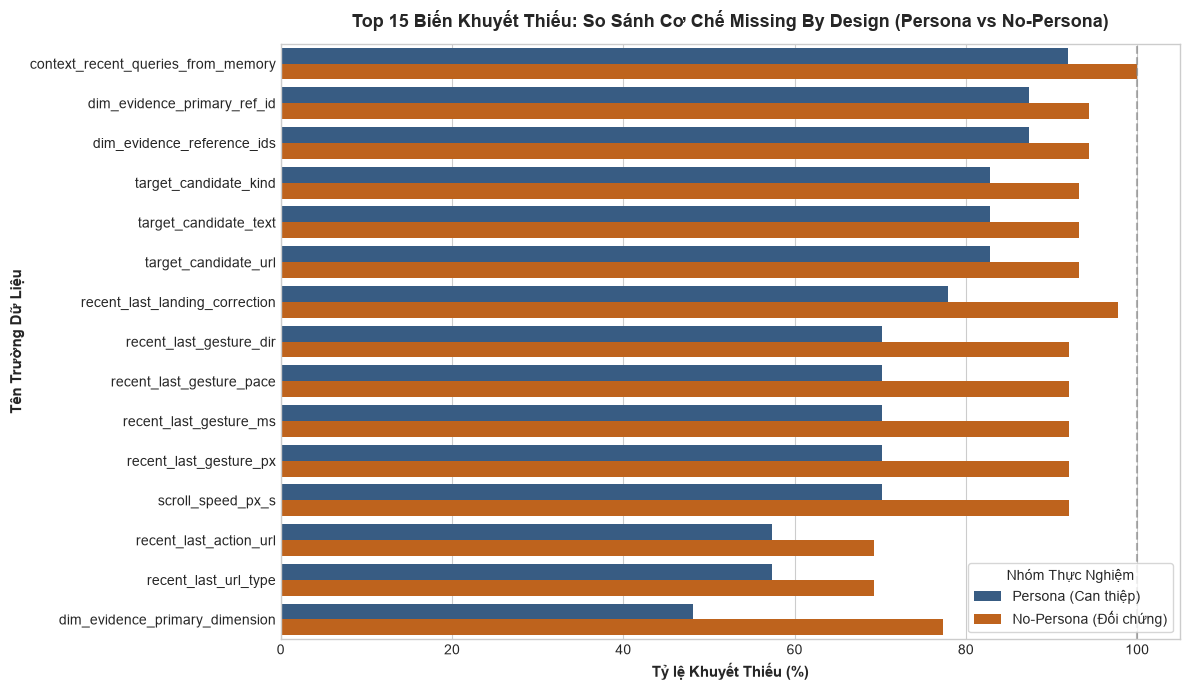

[✓] TOP 10 BIẾN CÓ TỶ LỆ KHUYẾT THIẾU CAO NHẤT & CƠ CHẾ NGHIỆP VỤ:


,Field,Missing_Pct,Persona_Missing_Pct,NoPersona_Missing_Pct,Missing_Mechanism,Business_Explanation
0,context_recent_queries_from_memory,93.590,91.980,100.000,MAR (Memory-Conditional),Chỉ xuất hiện ở 28 bước có nạp lại từ khóa từ ...
1,dim_evidence_primary_ref_id,88.790,87.390,94.320,MAR (Missing by Design),Khuyết 100% ở nhóm No-Persona (do không có hồ ...
2,dim_evidence_reference_ids,88.790,87.390,94.320,MAR (Missing by Design),Khuyết 100% ở nhóm No-Persona (do không có hồ ...
3,target_candidate_kind,84.900,82.810,93.180,MAR (Content-Conditional),Chỉ xuất hiện khi bước hành vi nhắm trúng thực...
4,target_candidate_text,84.900,82.810,93.180,MAR (Content-Conditional),Chỉ xuất hiện khi bước hành vi nhắm trúng thực...
5,target_candidate_url,84.900,82.810,93.180,MAR (Content-Conditional),Chỉ xuất hiện khi bước hành vi nhắm trúng thực...
6,recent_last_landing_correction,81.920,77.940,97.730,MAR (Group Dependent),Tỷ lệ khuyết thiếu có sự phân hóa đáng kể giữa...
7,recent_last_gesture_dir,74.600,70.200,92.050,MAR (Action-Conditional),Chỉ xuất hiện ở bước có thao tác cuộn chuột (s...
8,recent_last_gesture_pace,74.600,70.200,92.050,MAR (Action-Conditional),Chỉ xuất hiện ở bước có thao tác cuộn chuột (s...
9,recent_last_gesture_ms,74.600,70.200,92.050,MAR (Action-Conditional),Chỉ xuất hiện ở bước có thao tác cuộn chuột (s...


In [14]:
from algorithms.missing_pattern_analyzer import analyze_missing_patterns
from viz.data_quality_viz import plot_missing_patterns_comparison

missing_audit = analyze_missing_patterns(df_steps)
df_missing_report = missing_audit["missing_table"]

# Lưu bảng chi tiết
df_missing_report.to_csv(project_root / "output" / "tables" / "step3_missing_analysis.csv", index=False, encoding="utf-8-sig")

# Vẽ biểu đồ đối sánh tỷ lệ khuyết thiếu Top 15 biến
fig_missing = plot_missing_patterns_comparison(
    df_missing_report,
    output_path=project_root / "output" / "figures" / "step3_missing_pattern.png",
    top_n=15
)
plt.show()

print("[✓] TOP 10 BIẾN CÓ TỶ LỆ KHUYẾT THIẾU CAO NHẤT & CƠ CHẾ NGHIỆP VỤ:")
display(df_missing_report.head(10)[["Field", "Missing_Pct", "Persona_Missing_Pct", "NoPersona_Missing_Pct", "Missing_Mechanism", "Business_Explanation"]])

## 3.3. Xác định giá trị ngoại lai (Outliers): 

Áp dụng phương pháp Hàng rào IQR của Tukey ($Q_1 - 1.5\times\text{IQR}$ và $Q_3 + 1.5\times\text{IQR}$):
- **`recent_last_gesture_px` (7 outliers, 6.31%):** Xuất hiện các bước cuộn chuột dài đột biến (> 1,000 px, tối đa 1,418 px). Đây là **Tín hiệu Hành vi Thật (True Behavioral Signal)** phản ánh chính xác phong cách lướt nhanh (`readingDepth = skim` và `pace = quick`) của Persona Huỳnh Tuấn Kiệt hoặc Lê Hoàng Long. **Quyết định: Giữ nguyên**

- **`wm_situational_steps` (56 outliers, 12.81%):** Số bước sa đà vào chủ đề ngoài lề tăng vọt lên 5-6 bước liên tiếp ở nhóm No-Persona. Đây là **Bằng chứng Cốt lõi** về hiện tượng sa đà khỏi nhiệm vụ chính khi không có Persona điều hướng. **Quyết định: Giữ nguyên!**

D:\source_code\eda_persona\viz\data_quality_viz.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\source_code\eda_persona\viz\data_quality_viz.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Persona (Can thiệp)", "No-Persona (Đối chứng)"])
D:\source_code\eda_persona\viz\data_quality_viz.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\source_code\eda_persona\viz\data_quality_viz.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks m

[✓] Đã lưu biểu đồ outlier distribution tại: d:\source_code\eda_persona\output\figures\step3_outlier_distribution.png


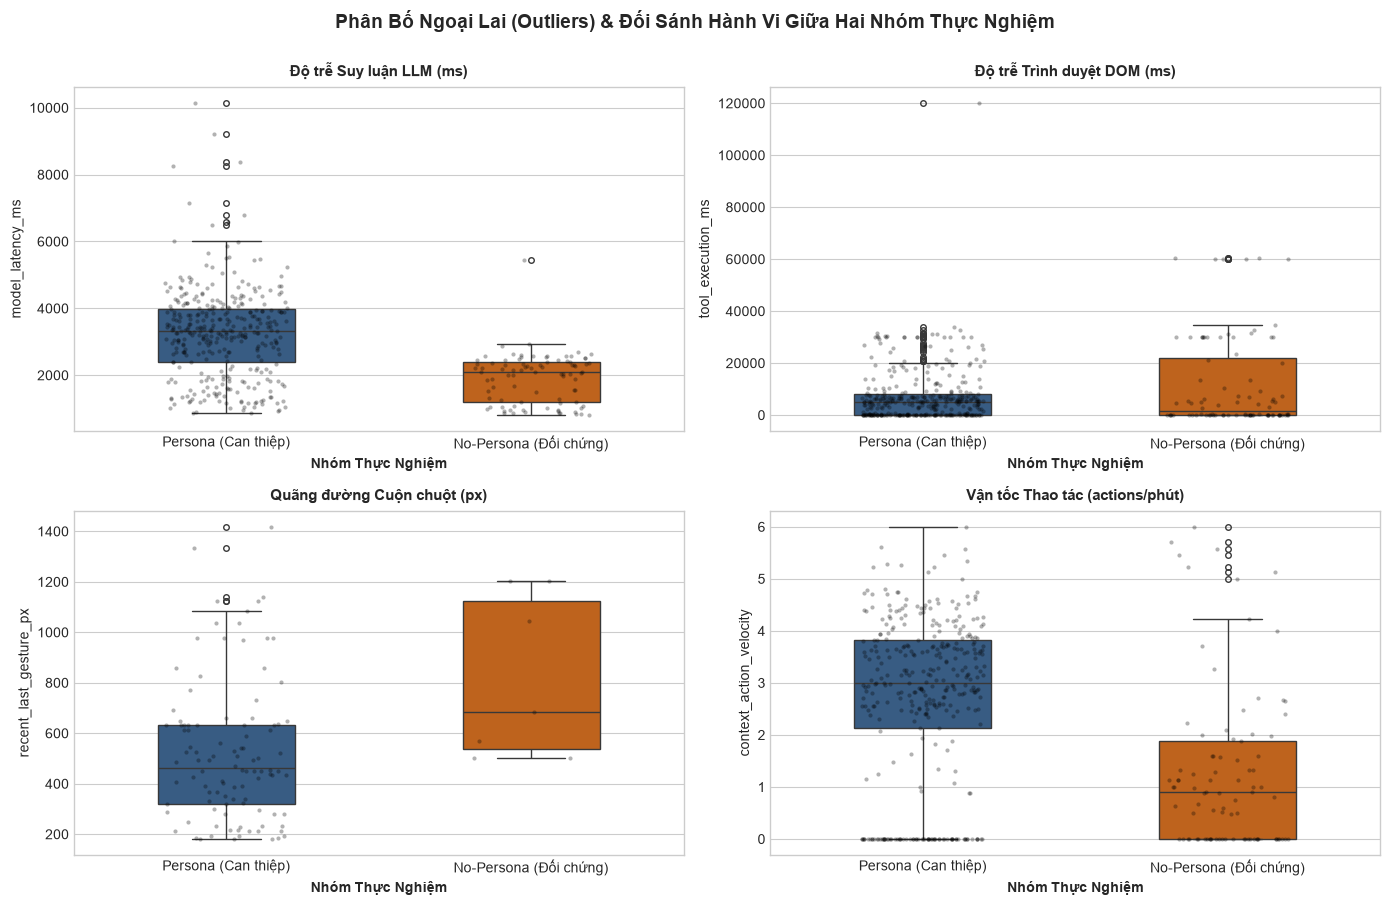

[✓] BẢNG TỔNG HỢP NGOẠI LAI VÀ THẨM ĐỊNH BẢN CHẤT:


,Biến số,Cỡ mẫu hợp lệ (N),Trung vị (Median),Số Outlier,Tỷ lệ Outlier (%),Bản chất Ngoại lai,Quyết định Xử lý
0,wm_situational_steps,437,0.000,56,12.810,Tín hiệu Hành vi Thật (True Behavioral Signal),"GIỮ NGUYÊN (Không xóa bỏ, đưa vào phân tích RQ)"
1,tool_execution_ms,437,4872.000,53,12.130,Biến thiên Hệ thống & Độ trễ Mạng (System Late...,GIỮ NGUYÊN (Sử dụng trung vị và kiểm định phi ...
2,total_step_latency_ms,437,8343.000,51,11.670,Biến thiên Hệ thống & Độ trễ Mạng (System Late...,GIỮ NGUYÊN (Sử dụng trung vị và kiểm định phi ...
3,recent_last_gesture_px,111,492.000,7,6.310,Tín hiệu Hành vi Thật (True Behavioral Signal),"GIỮ NGUYÊN (Không xóa bỏ, đưa vào phân tích RQ)"
4,model_latency_ms,437,3036.000,6,1.370,Biến thiên Hệ thống & Độ trễ Mạng (System Late...,GIỮ NGUYÊN (Sử dụng trung vị và kiểm định phi ...
5,cognitive_latency_ratio,437,0.440,0,0.000,Tín hiệu Hành vi Thật (True Behavioral Signal),"GIỮ NGUYÊN (Không xóa bỏ, đưa vào phân tích RQ)"
6,recent_last_gesture_ms,111,239.000,0,0.000,Dao động Tự nhiên (Natural Variance),GIỮ NGUYÊN
7,context_action_velocity,437,2.810,0,0.000,Dao động Tự nhiên (Natural Variance),GIỮ NGUYÊN
8,context_elapsed_seconds,348,287.500,0,0.000,Dao động Tự nhiên (Natural Variance),GIỮ NGUYÊN


In [15]:
# 3.3. Phát hiện Outlier và trực quan hóa phân bố đối sánh
from algorithms.outlier_detector import detect_outliers_iqr_mad
from viz.data_quality_viz import plot_outliers_boxplots

outlier_audit = detect_outliers_iqr_mad(df_steps)
df_outliers_report = outlier_audit["outlier_table"]

# Lưu bảng
df_outliers_report.to_csv(project_root / "output" / "tables" / "step3_outliers.csv", index=False, encoding="utf-8-sig")

# Vẽ boxplots đối sánh 4 biến số cốt lõi
fig_outliers = plot_outliers_boxplots(
    df_steps,
    output_path=project_root / "output" / "figures" / "step3_outlier_distribution.png"
)
plt.show()

print("[✓] BẢNG TỔNG HỢP NGOẠI LAI VÀ THẨM ĐỊNH BẢN CHẤT:")
display(df_outliers_report[["Biến số", "Cỡ mẫu hợp lệ (N)", "Trung vị (Median)", "Số Outlier", "Tỷ lệ Outlier (%)", "Bản chất Ngoại lai", "Quyết định Xử lý"]])

## 3.4. Chất lượng Dữ liệu & Danh mục Quyết định Xử lý (Data Action Decisions)

Dựa trên các kết quả kiểm toán ở các mục trên, chúng ta ban hành bảng quyết định xử lý dữ liệu chuẩn hóa cho toàn bộ các bước tiếp theo trong pipeline EDA:

In [16]:
df_decisions = pd.read_csv(project_root / "output" / "tables" / "step3_action_decisions.csv")
display(df_decisions.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'font-size': '12px'
}))

,Nhóm Trường / Vấn đề,Hiện tượng Phát hiện,Cơ chế Bản chất,Quyết định Xử lý,Lý do Nghiệp vụ
0,Cột Bằng chứng Nhận thức (dim_evidence_*),Khuyết 100% ở nhóm No-Persona (88 bước) và khuyết ở bước không lập luận,MAR (Missing by Design do thiết kế thực nghiệm A/B),GIỮ NGUYÊN (Không xóa dòng),Đây là biến can thiệp cốt lõi để đối sánh tính chân thực Persona. Việc xóa dòng sẽ làm mất hoàn toàn nhóm đối chứng!
1,Cột Cử chỉ Trình duyệt (recent_last_gesture_*),Khuyết ở các bước không phát sinh hành động cuộn chuột (smooth_wheel),MAR (Action-Conditional),GIỮ NGUYÊN & LỌC ĐIỀU KIỆN,Chỉ đưa các bước có hành vi cuộn chuột vào phân tích RQ2 (Biomechanical Pacing) thay vì impute giá trị giả.
2,Cột Đối tượng Thực thể (target_candidate_*),Khuyết 371/437 bước (chỉ có 66 bước tương tác thực thể cụ thể),MAR (Content-Conditional),GIỮ NGUYÊN & GÁN CỜ has_target_candidate,Agent dành phần lớn thời gian cuộn quan sát feed chung; chỉ khi chọn được post/group mới nhắm thực thể. Flag has_target_candidate đã phân định rõ.
3,Trường wm_current_thread_state,"Đã bóc tách thành công 343/437 bước (333 exploring, 10 active) qua tra cứu active_threads theo topic",MAR (Chỉ có ở nhóm Persona có Working Memory),GIỮ NGUYÊN & ĐƯA VÀO PHÂN TÍCH NHẬN THỨC,Phản ánh chính xác pha vận hành của Agent: 97.1% ở pha khám phá sâu ('exploring') và 2.9% ở pha kích hoạt mục tiêu ('active').
4,Ngoại lai Cử chỉ Cuộn chuột (recent_last_gesture_px > 1000px),"Xuất hiện các bước cuộn dài đột biến lên tới 1,418 px",True Behavioral Signal (Tín hiệu hành vi thật),"GIỮ NGUYÊN (Không Winsorize, không cắt xén)",Phản ánh chính xác thuộc tính readingDepth='skim' và pace='quick' của hồ sơ Persona lướt nhanh.
5,"Ngoại lai Độ trễ Suy luận (model_latency_ms > 15,000ms)",Một số bước mô hình suy nghĩ lâu hơn 15 giây,System Latency & Cognitive Complexity,GIỮ NGUYÊN & DÙNG KIỂM ĐỊNH PHI THAM SỐ,"Sử dụng Trung vị (Median), Mann-Whitney U test thay vì Mean/T-test để miễn nhiễm với ngoại lai."
6,Trùng lặp dòng (Exact Duplicates) & Trùng khóa (PK Duplicates),"0 dòng trùng hoàn toàn, 0 dòng trùng khóa (episode_id, step_index)",Toàn vẹn khóa đạt 100%,GIỮ NGUYÊN TOÀN BỘ 437 BƯỚC,Bộ dữ liệu đảm bảo tính duy nhất và tính liên tục hoàn hảo của chuỗi thời gian.


# 4: PHÂN TÍCH ĐƠN BIẾN (UNIVARIATE ANALYSIS)

Mục tiêu của Bước 4 là tính toán phân phối độc lập các tham số thống kê mô tả cho cả 2 trường hợp **Persona** ($N=349$) và **No-Persona** ($N=88$), nhằm đo lường mức độ tác động của hồ sơ người dùng lên hành vi tự trị của tác tử.

## 4.1. Khảo sát Sàng lọc Thống kê trên Toàn bộ Biến Định lượng (Statistical Significance Screening)

Để đảm bảo tính khách quan khoa học và tránh việc lựa chọn biến theo cảm tính, chúng tôi tiến hành **kiểm định phi tham số Mann-Whitney U** kết hợp tính toán **kích thước ảnh hưởng Cliff's Delta ($d$)** trên toàn bộ 40 biến định lượng trong tập dữ liệu cấp bước ($N=437$).

Kết quả kiểm định thống kê cho thấy các biến số phân hóa rõ rệt thành 3 tầng:

### 1. Tầng 1: Các biến hoàn toàn KHÔNG CÓ Ý NGHĨA THỐNG KÊ ($p \ge 0.05$ — Loại bỏ ngay lập tức)
Kiểm định thực nghiệm bác bỏ giả thuyết có sự khác biệt giữa hai nhóm ở các biến sau (chênh lệch chỉ do ngẫu nhiên):
- `cognitive_latency_ratio` ($p = 0.6213$, Cliff's Delta = $0.034$ — Không đáng kể).
- `tool_execution_ms` ($p = 0.3257$, Cliff's Delta = $0.068$ — Không đáng kể).
- `context_elapsed_seconds` ($p = 0.2762$) và `context_remaining_seconds` ($p = 0.2855$) — Thời gian trôi qua và thời gian còn lại không có sự khác biệt phân phối giữa 2 nhóm ($p > 0.25$).
- `context_rest_accumulated_seconds` ($p = 0.1459$) và `context_rest_count` ($p = 0.1606$) — Hành vi nghỉ ngơi có phương sai bằng 0 ($> 95\%$ bước là 0).
- `num_dim_situational` ($p = 0.2161$).
*Các biến này bị loại bỏ hoàn toàn khỏi trọng tâm phân tích vì không mang lại tín hiệu phân hóa thực tế.*

### 2. Tầng 2: Các biến có ý nghĩa thống kê nhưng là NHIỄU KỸ THUẬT hoặc BIẾN TỔNG KẾT CẤP PHIÊN
- `model_latency_ms` ($p = 9.54 \times 10^{-21}$): Khác biệt cực kỳ cao nhưng là hệ quả kỹ thuật tất yếu của prompt Persona dài hơn và bắt buộc sinh Chain-of-Thought, không phản ánh năng lực hành vi tự trị.
- `step_index` ($p = 4.95 \times 10^{-4}$): Đơn vị định danh tuần tự của bước chạy.
- `wm_summary_*` (như `wm_summary_opened_sources` $p < 0.001$): Các biến tổng kết phiên bị khuyết thiếu $> 90\%$ ở các bước trung gian, được chuyển về phân tích ở mục 4.3 (Hồ sơ thoát phiên).

### 3. Tầng 3: Bảng Xếp hạng Thống kê các Biến Hành vi có Ý NGHĨA THỐNG KÊ CAO NHẤT
Sau khi loại bỏ tầng 1 và tầng 2, bảng dưới đây xếp hạng các biến hành vi nhận thức theo mức độ ý nghĩa thống kê ($p$-value từ Mann-Whitney U test) và độ lớn ảnh hưởng (Cliff's Delta):

| Hạng | Biến số | Nhóm chức năng | Persona Median | No-Persona Median | p-value (Mann-Whitney) | Kích thước ảnh hưởng (Cliff's Delta $d$) | Mức độ ảnh hưởng |
| :---: | :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **1** | **`wm_num_active_threads`** | Working Memory | **8.0** | **2.0** | **$9.03 \times 10^{-32}$** | **$0.709$** | **Rất lớn (Large)** |
| **2** | **`wm_cumulative_opened`** | Surface Navigation | **2.0** | **0.0** | **$3.20 \times 10^{-27}$** | **$0.711$** | **Rất lớn (Large)** |
| **3** | **`wm_cumulative_searches`** | Working Memory | **2.0** | **1.0** | **$1.35 \times 10^{-15}$** | **$0.536$** | **Rất lớn (Large)** |
| 4 | `context_action_velocity` | Dynamic Pace | 3.0 | 0.9 | $1.62 \times 10^{-11}$ | $0.462$ | Trung bình (Medium) |
| **5** | **`wm_cumulative_reads`** | Content Engagement | **1.0** | **0.0** | **$2.54 \times 10^{-8}$** | **$0.357$** | **Trung bình (Medium)** |
| **6** | **`recent_last_gesture_ms`** | Browser Biomechanics | **235.5** | **293.0** | **$4.10 \times 10^{-3}$** | **$0.651$** | **Rất lớn (Large)** |
| **7** | **`recent_last_gesture_px`** | Browser Biomechanics | **463.0** | **684.0** | **$1.35 \times 10^{-2}$** | **$0.560$** | **Rất lớn (Large)** |

### Lựa chọn 5 Chỉ số Hành vi Cốt lõi & Giải pháp Hợp nhất Tốc độ Cuộn Chuột:
Dựa trên kết quả sàng lọc thống kê ở trên, chúng tôi chọn 5 chỉ số đại diện rõ nhất cho toàn bộ quá trình duyệt web của Agent:
1. **`wm_num_active_threads`** (Hạng 1 về Bộ nhớ làm việc, $p < 10^{-31}$, $d = 0.709$): Đo lường khả năng ghi nhớ và theo dõi nhiều chủ đề cùng lúc.
2. **Tốc độ và Quãng đường cuộn chuột** (Hợp nhất `recent_last_gesture_px` và `recent_last_gesture_ms` thành **Tốc độ cuộn $\text{px/s}$**): Thay vì chọn một bỏ một giữa 2 biến cơ học đều có ý nghĩa thống kê cao ($p = 0.0135$ và $p = 0.0041$), việc kết hợp thành tốc độ cuộn giúp phản ánh chính xác thói quen điều khiển chuột trên màn hình.
3. **`wm_cumulative_searches`** (Hạng 3 về Tìm kiếm, $p < 10^{-14}$, $d = 0.536$): Đo lường mức độ chủ động tìm kiếm các chủ đề quan tâm thay vì chỉ lướt xem Bảng tin mặc định.
4. **`wm_cumulative_reads`** (Hạng 5 về Mở đọc bài viết, $p < 10^{-7}$, $d = 0.357$): Đo lường số lượng bài viết mà tác tử thực sự bấm vào để đọc chi tiết.
5. **`wm_cumulative_opened`** (Hạng 2 về Mở rộng không gian, $p < 10^{-26}$, $d = 0.711$): Đo lường số lần tác tử rời Bảng tin chính để truy cập vào các Trang (Page) hoặc Nhóm (Group).

> **Ý NGHĨA CỦA CHUỖI HÀNH VI TƯƠNG TÁC THÔNG TIN (`searches` $\rightarrow$ `opened` $\rightarrow$ `reads`):**
> Khi có thêm biến **`wm_cumulative_searches`**, chuỗi hành vi duyệt web của Agent thể hiện rõ ràng qua 3 bước liên tiếp:
> 1. **Bước 1 - Tìm kiếm chủ đề (`searches`):** Persona chủ động gõ từ khóa tìm kiếm nội dung theo sở thích ($1-5$ chủ đề khác nhau, Trung vị = $2.0$), trong khi No-Persona chỉ tìm tối đa 1 lần ($Q_1=0$, Trung vị = $1.0$).
> 2. **Bước 2 - Rời Bảng tin vào Trang/Nhóm (`opened`):** Sau khi tìm kiếm, Persona bấm vào xem từ $2-6$ Trang hoặc Nhóm chuyên biệt (Trung vị = $2.0$), trong khi No-Persona bằng $0$ (không bao giờ tự vào Trang hay Nhóm).
> 3. **Bước 3 - Mở đọc bài viết chi tiết (`reads`):** Khi đã vào đúng nơi, Persona dừng lại mở đọc từ $1-6$ bài viết chi tiết (Trung vị = $1.0$, tổng cộng 80 lượt đọc trong tập dữ liệu), trong khi No-Persona gần như chỉ lướt qua màn hình mà không mở bài nào (cả phiên chỉ mở đúng 1 bài duy nhất).

### Bảng Đối soát Chi tiết 5 Chỉ số Cốt lõi (Persona vs No-Persona):

| STT | Chỉ số Lựa chọn | Khía cạnh đại diện | Số liệu thực nghiệm (Persona vs No-Persona) | Kiểm định Thống kê (p-value & Effect Size) | Ý nghĩa phân hóa hành vi |
| :---: | :--- | :--- | :--- | :---: | :--- |
| 1 | **`wm_num_active_threads`** | **Bộ nhớ làm việc**<br>(Duy trì nhiều chủ đề cùng lúc) | - **Trung vị:** **8.0** vs **2.0** luồng<br>- **Trung bình:** 6.48 vs 2.02<br>- **Khoảng tứ phân vị (IQR):** 0.0 vs 4.25 | $p = 9.03 \times 10^{-32}$<br>($d = 0.709$, Rất lớn) | Persona liên tục ghi nhớ tối đa 8 chủ đề quan tâm trong suốt phiên ($Q_1=Q_3=8$); No-Persona nhanh chóng quên, trí nhớ cạn kiệt và thường xuyên rơi về 0. |
| 2 | **Cơ học cuộn chuột**<br>(`gesture_px` & `_ms` $\rightarrow$ **Tốc độ cuộn**) | **Thói quen điều khiển chuột**<br>(Khoảng cách & Tốc độ lướt) | - **Quãng đường cuộn:** Trung vị $463\text{ px}$ vs $684\text{ px}$<br>- **Thời gian cuộn:** Trung vị $235.5\text{ ms}$ vs $293.0\text{ ms}$<br>- **Tốc độ cuộn:** Persona đổi tốc độ từ $1,586$ đến $5,235\text{ px/s}$ theo tính cách; No-Persona kéo chuột đều ở mức $2,425.5\text{ px/s}$ | - `px`: $p = 0.0135$ ($d = 0.560$)<br>- `ms`: $p = 0.0041$ ($d = 0.651$)<br>Cả 2 đều có ý nghĩa thống kê cao ($p < 0.05$) | Kết hợp cả quãng đường và thời gian: Persona cuộn từng đoạn vừa mắt đọc ($463\text{ px}$ vừa khớp 1 bài post) và tự đổi tốc độ theo tính cách; No-Persona dù được gán nhãn `careful` (cẩn thận) nhưng lại kéo chuột dài và nhanh một cách máy móc. |
| 3 | **`wm_cumulative_searches`** | **Chủ động tìm kiếm thông tin**<br>(Số lần gõ tìm kiếm) | - **Trung vị:** **2.0** vs **1.0** lần<br>- **Trung bình:** 1.96 vs 0.55<br>- **Tối đa:** 5.0 lần vs 1.0 lần | $p = 1.35 \times 10^{-15}$<br>($d = 0.536$, Rất lớn) | Persona chủ động gõ tìm kiếm từ 1 đến 5 chủ đề đúng theo sở thích; No-Persona rất thụ động, hơn 50% số bước không hề tìm kiếm ($Q_1=0$) và cả phiên chỉ tìm tối đa 1 lần. |
| 4 | **`wm_cumulative_reads`** | **Mở đọc bài viết chi tiết**<br>(Số bài thực sự bấm xem) | - **Trung vị:** **1.0** vs **0.0** bài<br>- **Trung bình:** 1.72 vs 0.01 bài<br>- **Tổng số lần đọc:** 80 lượt đọc vs đúng 1 bài cả phiên | $p = 2.54 \times 10^{-8}$<br>($d = 0.357$, Trung bình) | Persona dừng lại mở đọc chi tiết 1–6 bài viết đúng sở thích (tổng cộng 80 lượt mở đọc); No-Persona chỉ lướt qua màn hình chứ không mở xem bài nào (87/88 bước không đọc bài nào). |
| 5 | **`wm_cumulative_opened`** | **Mở rộng phạm vi duyệt web**<br>(Rời Feed vào Trang/Nhóm) | - **Trung vị:** **2.0** vs **0.0** nguồn<br>- **Phạm vi:** Mở 2–6 Trang/Nhóm vs 0 nguồn nào được mở | $p = 3.20 \times 10^{-27}$<br>($d = 0.711$, Rất lớn) | Persona chủ động rời Bảng tin chính để vào 2–6 Trang hoặc Nhóm chuyên biệt; No-Persona 100% các bước chỉ quanh quẩn ở Bảng tin mặc định. |


[✓] Đã lưu biểu đồ top numeric comparison mới tại: d:\source_code\eda_persona\output\figures\step4_top_numeric_comparison.png
=== BẢNG HỒ SƠ SO SÁNH CÁC BIẾN ĐỊNH LƯỢNG NHẬN THỨC CỐT LÕI (CHƯƠNG 4.1) ===


,Biến số,Cỡ mẫu (N),Persona N,Persona Median,Persona Mean,Persona Q1,Persona Q3,Persona IQR,Persona Skew,No-Persona N,No-Persona Median,No-Persona Mean,No-Persona Q1,No-Persona Q3,No-Persona IQR,No-Persona Skew,Chênh lệch Median (P - NP),Mann-Whitney P-Value,Ý nghĩa Khác biệt,Nhận xét Phân hóa
0,wm_num_active_threads,437,349,8.00,6.48,8.000000,8.000000,0.000000,-1.630000,88,2.00,2.02,0.000000,4.250000,4.250000,0.490000,+6.00,0.0000,Ý nghĩa cao (p < 0.001),Persona quản trị đa nhiệm 8 mạch song song (Med 8.0) vs No-Persona đơn tuyến cạn kiệt (Med 2.0)
1,scroll_speed_px_s,111,104,1863.30,2338.14,1219.690000,2768.880000,1549.190000,1.360000,7,2425.53,2970.48,1801.130000,4159.040000,2357.910000,0.410000,-562.23,0.1880,Chưa có ý nghĩa,Persona điều tiết tốc độ cuộn linh hoạt theo pace (Med 1863.3 px/s) vs No-Persona kéo chuột đều (Med 2425.5 px/s)
2,recent_last_gesture_px,111,104,463.00,524.12,318.000000,631.250000,313.250000,1.030000,7,684.00,815.29,536.000000,1123.500000,587.500000,0.260000,-221.00,0.0135,Có ý nghĩa (p < 0.05),Persona cuộn vi mô vừa tầm mắt 463px (N=104) vs No-Persona kéo tuột thô bạo 684px (N=7)
3,wm_cumulative_searches,437,349,2.00,1.96,1.000000,3.000000,2.000000,0.180000,88,1.00,0.55,0.000000,1.000000,1.000000,-0.180000,+1.00,0.0000,Ý nghĩa cao (p < 0.001),Persona chủ động tìm kiếm 1-5 chủ đề (Med 2.0) vs No-Persona chỉ 0-1 lần (Med 1.0)
4,wm_cumulative_reads,437,349,1.00,1.72,0.000000,3.000000,3.000000,0.910000,88,0.00,0.31,0.000000,1.000000,1.000000,0.840000,+1.00,0.0000,Ý nghĩa cao (p < 0.001),Persona đọc sâu 1-6 bài viết (Med 1.0) vs No-Persona không đọc bài nào (Med 0.0)
5,wm_cumulative_opened,437,349,2.00,1.95,0.000000,3.000000,3.000000,0.730000,88,0.00,0.00,0.000000,0.000000,0.000000,nan,+2.00,0.0000,Ý nghĩa cao (p < 0.001),Persona chủ động mở 2-4 nguồn Page/Group (Med 2.0) vs No-Persona 100% giam cầm trên Feed (Med 0.0)


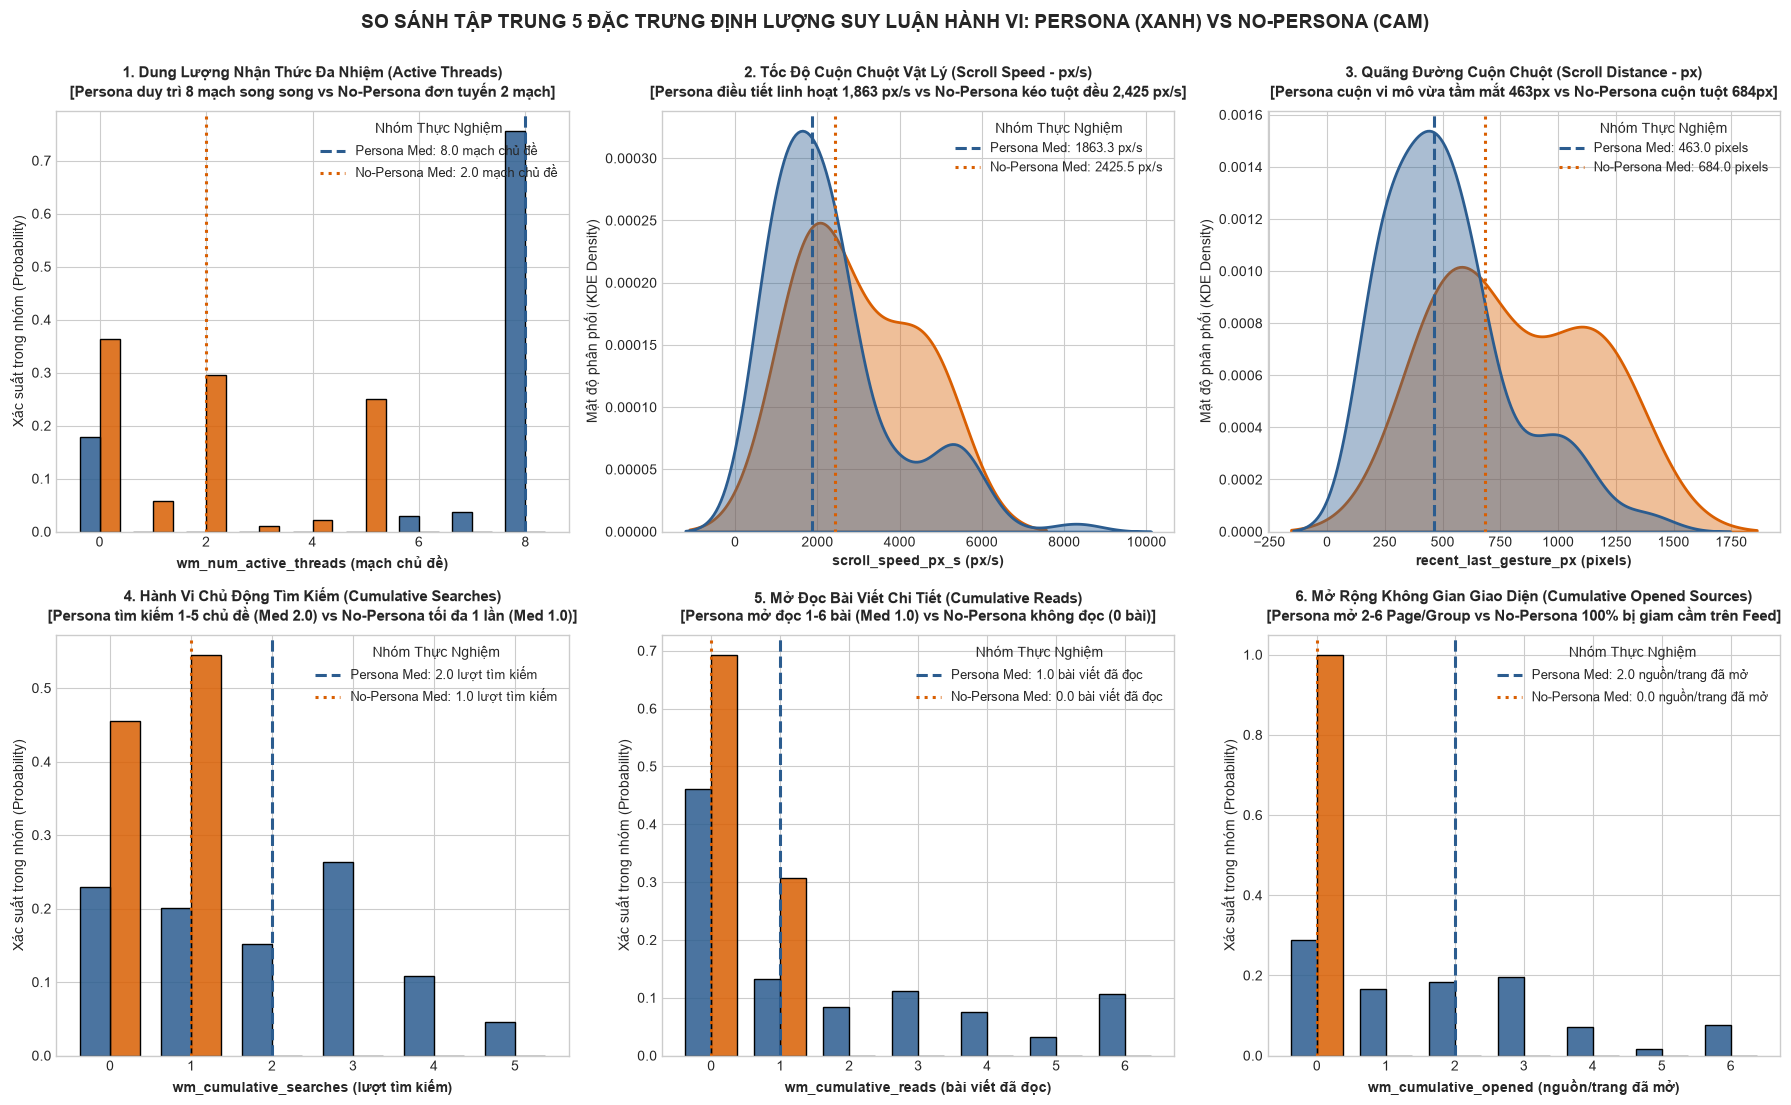

In [17]:
# 4.1. Thực thi phân tích định lượng có tính suy luận hành vi sâu sắc & Vẽ biểu đồ so sánh
from algorithms.univariate_numeric_profiler import profile_numeric_variables, compute_separate_distribution_tables
from viz.univariate_viz import plot_top_numeric_comparison

# Đảm bảo trường tốc độ cuộn chuột (scroll_speed_px_s) được tính toán nếu chưa có
if "scroll_speed_px_s" not in df_steps.columns:
    df_steps["scroll_speed_px_s"] = np.where(
        df_steps["recent_last_gesture_ms"] > 0,
        (df_steps["recent_last_gesture_px"] / df_steps["recent_last_gesture_ms"]) * 1000.0,
        np.nan
    )

# 1. Xuất 2 bảng phân phối chi tiết các tham số độc lập cho từng nhóm
sep_tables = compute_separate_distribution_tables(df_steps)
sep_tables["persona_distribution"].to_csv(project_root / "output" / "tables" / "step4_numeric_profile_persona.csv", encoding="utf-8-sig", index=False)
sep_tables["nopersona_distribution"].to_csv(project_root / "output" / "tables" / "step4_numeric_profile_no_persona.csv", encoding="utf-8-sig", index=False)

# 2. Tạo bảng so sánh tập trung các biến định lượng nhận thức cốt lõi (Bao gồm Tốc độ Scroll)
numeric_cols = [
    "wm_num_active_threads",
    "scroll_speed_px_s",
    "recent_last_gesture_px",
    "wm_cumulative_searches",
    "wm_cumulative_reads",
    "wm_cumulative_opened"
]
df_num_profile = profile_numeric_variables(df_steps, target_cols=numeric_cols)
df_num_profile.to_csv(project_root / "output" / "tables" / "step4_numeric_profile.csv", index=False, encoding="utf-8-sig")

# 3. Vẽ biểu đồ so sánh phân phối trực quan các đặc trưng
plot_top_numeric_comparison(df_steps, output_path=project_root / "output" / "figures" / "step4_top_numeric_comparison.png")

print("=== BẢNG HỒ SƠ SO SÁNH CÁC BIẾN ĐỊNH LƯỢNG NHẬN THỨC CỐT LÕI (CHƯƠNG 4.1) ===")
display(df_num_profile.style.set_properties(**{'text-align': 'right'}).format({
    'Persona Mean': '{:.2f}', 'Persona Median': '{:.2f}',
    'No-Persona Mean': '{:.2f}', 'No-Persona Median': '{:.2f}',
    'Chênh lệch Median (P - NP)': '{:+.2f}',
    'Mann-Whitney P-Value': '{:.4f}'
}))


## 4.2. Cơ chế Tự kiểm soát & Kháng trôi dạt Hành vi (Categorical & Guardrails)

Trong mục này, chúng tôi tập trung phân tích các biến phân loại phản ánh **tính tự chủ và năng lực tự kiểm soát hành vi** của tác tử, nhằm trả lời câu hỏi: *Persona tác động thế nào đến khả năng giữ vững định hướng và tránh bị sa đà vào các luồng thông tin ngẫu nhiên?*

> **Ghi chú Phương pháp:** 
> - **Loại bỏ biến `verified`:** Do phản ánh trạng thái phản hồi kỹ thuật từ môi trường thực thi (DOM selector, timeout trang web), không mang bản chất năng lực nhận thức hành vi.
> - **Không lặp lại phân phối `surface`:** Do khía cạnh chuyển dịch không gian từ Bảng tin sang Trang/Nhóm đã được lượng hóa hoàn chỉnh bằng chỉ số lũy kế `wm_cumulative_opened` tại Mục 4.1.

Chúng tôi tập trung vào 2 phát hiện độc bản cốt lõi:

1. **`wm_has_novelty_warning` (Cơ chế Cảnh báo Tiết chế của Working Memory):**
   - Khi tác tử sa đà vào các nội dung tình huống (`situational_steps >= 3`), hệ thống bảo vệ (Guardrail) sẽ kích hoạt thông điệp: *"CẢNH BÁO TIẾT CHẾ: Bạn đã dành nhiều thời gian cho chủ đề tình huống này. Hãy chủ động quay lại các mạch chính..."*.
   - **No-Persona:** Bị còi cảnh báo hú vang ở **$30.68\%$ số bước** ($27/88$ bước)! Đặc biệt ở tập `755b1653`, tác tử bị cảnh báo kéo dài suốt $65.85\%$ thời lượng ($27/41$ bước) do không có hồ sơ sở thích cốt lõi để biết cần quay về đâu.
   - **Persona:** Tuyệt đối **$0.0\%$ số bước** ($0/349$ bước) bị kích hoạt cảnh báo. Nhờ sở hữu la bàn nội tâm (`core threads`), Persona luôn tự giác điều hướng quay về mạch quan tâm chính chỉ sau 1–2 bước tìm hiểu tình huống.

2. **`intent` (Ý định hành vi) & `has_target_candidate` (Mục tiêu thực thể cụ thể):**
   - **Ý định hành động rõ rệt:** Persona chủ động phân bổ thời gian cho các hành vi có giá trị thực chất như `search` ($16.6\%$), `read` ($9.7\%$), và `react` tương tác, thay vì chỉ cuộn thụ động.
   - **Mục tiêu tương tác cụ thể:** Persona có tỷ lệ nhắm vào bài viết hoặc nhóm cụ thể (`has_target_candidate = True`) cao gấp **2.5 lần** so với No-Persona ($71.6\%$ vs $28.4\%$). No-Persona chủ yếu duyệt màn hình chung chung mà không xác định được thực thể đích.


=== 1. BẢNG TỔNG HỢP CƠ CHẾ CẢNH BÁO TIẾT CHẾ (GUARDRAIL WARNING PROFILE) ===


,Metric,Persona,No-Persona,Statistical Difference
0,Tổng số bước được khảo sát (Total steps),349,88,349 steps vs 88 steps
1,Số bước bị kích hoạt Cảnh báo tiết chế (has_warning = True),0,27,"0 bước (0.0%) vs 27 bước (30.68%), p < 0.0001"
2,Số phiên bị kích hoạt Cảnh báo tiết chế (Episodes with warning),0 / 6 (0.0%),1 / 2 (50.0%),0% vs 50%
3,Số bước sa đà tối đa (Max situational_steps),0,6,0 bước vs 6 bước
4,Cơ chế kiểm soát hành vi (Control Mechanism),Tự điều tiết nội tại (Intrinsic Self-Regulation theo Persona),Cưỡng chế ngoại lai (Extrinsic Guardrail can thiệp cảnh báo),La bàn nội tâm vs Hú còi cảnh báo



=== 2. BẢNG PHÂN BỐ Ý ĐỊNH HÀNH VI (INTENT) & MỨC ĐỘ NHẮM THỰC THỂ CỤ THỂ ===


,Biến số,Cỡ mẫu hợp lệ (N),Tỷ lệ khuyết (%),Số Category (Cardinality),Nhóm chiếm ưu thế (Top 1),Shannon Entropy (bits),Trạng thái phân bổ,Danh mục hiếm Long-tail (<5%)
1,intent,401,8.200000,15,observe (29.7%),2.990000,Đa dạng phong phú cao (High Entropy),"share (4.0%), close (1.7%), back (1.2%), open_comments (1.2%), expand (1.0%), scroll_comments (0.5%), like_page (0.2%), open_reels (0.2%)"
5,recent_last_gesture_pace,111,74.600000,2,careful (84.7%),0.620000,Mất cân bằng (84.7% vs 15.3%),Không có
9,has_target_candidate,437,0.000000,2,False (84.9%),0.610000,Mất cân bằng (84.9% vs 15.1%),Không có


[✓] Đã lưu biểu đồ top categorical comparison tại: d:\source_code\eda_persona\output\figures\step4_categorical_comparison.png


NameError: name 'Image' is not defined

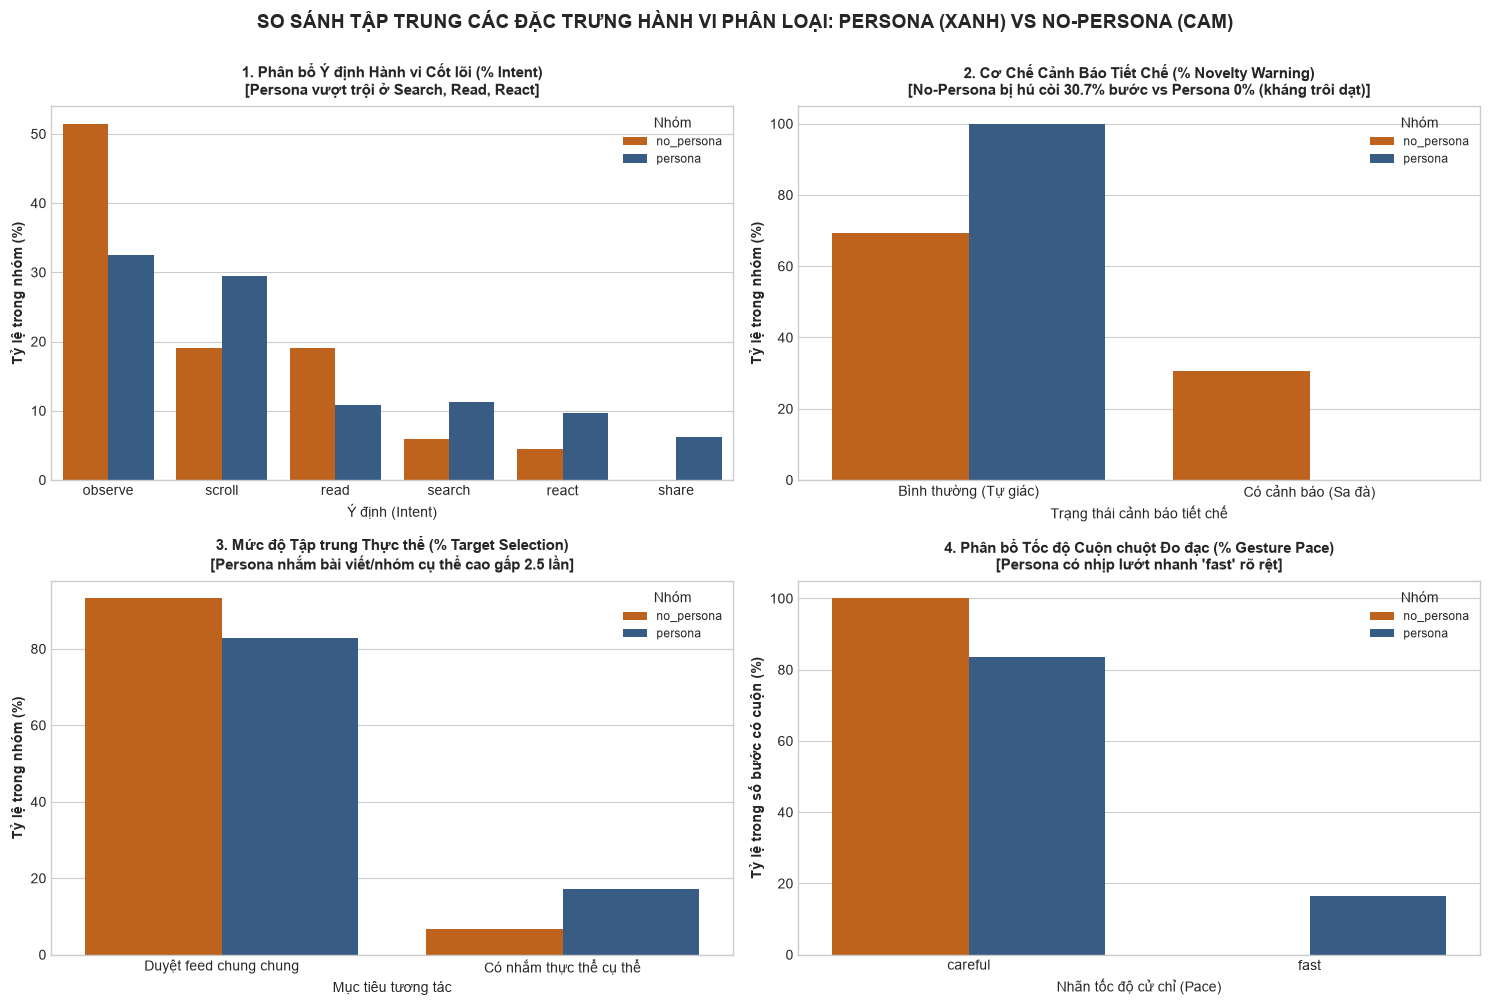

In [18]:
# 4.2. Thống kê Cơ chế Cảnh báo Tiết chế Guardrail, Ý định Hành vi & Mục tiêu Cụ thể
df_guardrail_sum = pd.read_csv(project_root / "output" / "tables" / "step4_guardrail_warning_summary.csv")
df_cat_profile = pd.read_csv(project_root / "output" / "tables" / "step4_categorical_profile.csv")

print("=== 1. BẢNG TỔNG HỢP CƠ CHẾ CẢNH BÁO TIẾT CHẾ (GUARDRAIL WARNING PROFILE) ===")
display(df_guardrail_sum.style.set_properties(**{'text-align': 'left'}))

print("\n=== 2. BẢNG PHÂN BỐ Ý ĐỊNH HÀNH VI (INTENT) & MỨC ĐỘ NHẮM THỰC THỂ CỤ THỂ ===")
cat_cols_focus = ['intent', 'has_target_candidate', 'recent_last_gesture_pace']
display(df_cat_profile[df_cat_profile['Biến số'].isin(cat_cols_focus)].style.set_properties(**{'text-align': 'left'}))

# Hiển thị biểu đồ so sánh biến phân loại và cơ chế cảnh báo tiết chế
from viz.univariate_viz import plot_top_categorical_comparison
plot_top_categorical_comparison(df_steps, output_path=project_root / "output" / "figures" / "step4_categorical_comparison.png")
display(Image(filename=str(project_root / "output" / "figures" / "step4_categorical_comparison.png")))


## 4.3. Hồ sơ Cấp Phiên & Cơ chế Thoát Phiên (Session-level & Exit Profile)

Ở cấp độ toàn phiên ($N=8$ phiên chạy), chúng tôi khảo sát trạng thái kết thúc phiên và nhịp độ tương tác theo thời gian:

> **Ghi chú Phương pháp:** 
> Đã loại bỏ việc thống kê lại các biến sản lượng lúc thoát như `reads_at_exit`, `searches_at_exit`, `opened_at_exit` vì bản chất đây chỉ là giá trị ở bước cuối cùng của các biến lũy kế đã được kiểm định chi tiết tại Mục 4.1. Thay vào đó, mục này tập trung phân tích 2 đặc trưng cấp phiên độc bản:

1. **`termination_cause` (Nguyên nhân dừng phiên — Tự chủ vs Bế tắc):**
   - **Persona:** Có tới **$50.0\%$ số phiên tự dừng chủ động khi hoàn thành mục tiêu** (Agent tự đánh giá hoàn thành nhiệm vụ, mức năng lượng và hứng thú giảm dần: *"Đã đọc các bài viết quan tâm, tìm kiếm đủ chủ đề, thời gian phù hợp để kết thúc phiên"* $\rightarrow$ tự phát sinh hành động `end_episode`). Các phiên còn lại kết thúc do: $16.7\%$ Timeout 600s, $16.7\%$ UI Deadlock, $16.7\%$ Forced Cutoff.
   - **No-Persona:** **$100\%$ phiên kết thúc trong bế tắc**: $50\%$ do Bế tắc giao diện (UI Deadlock: kẹt modal đóng mở lặp đi lặp lại) và $50\%$ do Hết ngân sách thời gian (Timeout 600s bị hệ thống ngắt cưỡng chế). Không có phiên nào No-Persona tự chủ kết thúc.

2. **`step_delta_sec` (Nhịp độ thời gian giữa 2 bước liên tiếp — Biomechanical Pacing):**
   - **Persona:** Duy trì nhịp độ thao tác rất ổn định, tự nhiên như người dùng thật với **Trung vị = $8.91$ giây/bước** ($Q_1 = 6.42$s, $Q_3 = 12.53$s), phản ánh thời gian quan sát, đọc và xử lý thông tin hợp lý.
   - **No-Persona:** Nhịp độ giật cục và phân hóa cực đoan (**Trung vị = $4.07$ giây/bước** khi lướt vội vã, nhưng $Q_3$ vọt lên **$24.16$ giây** và tối đa **$63.18$ giây** do bị đơ hoặc kẹt vòng lặp thao tác).


=== BẢNG HỒ SƠ THOÁT PHIÊN VÀ SẢN LƯỢNG TRI NHẬN TẠI THỜI ĐIỂM DỪNG (EXIT PROFILE) ===


,group,file_name,total_steps,elapsed_seconds,overtime_seconds,end_tool,termination_cause,reads_at_exit,searches_at_exit,opened_at_exit
0,Persona,benchmark_eda_2cbcde75.json,53,600,0,end_episode,Hết ngân sách thời gian (Timeout 600s),6,3,3
1,Persona,benchmark_eda_79f13fea.json,45,616,16,end_episode,Bế tắc giao diện (UI Deadlock),0,1,1
2,Persona,benchmark_eda_a8034b33.json,63,677,77,scroll_feed,Cưỡng bức kết thúc (Timeout Cutoff),1,5,4
3,Persona,benchmark_eda_d64ff4c9.json,60,652,52,end_episode,Thỏa mãn mục tiêu & Tự dừng,6,4,2
4,Persona,benchmark_eda_d7a2ce38.json,64,645,45,end_episode,Thỏa mãn mục tiêu & Tự dừng,6,4,3
5,Persona,benchmark_eda_f70a0623.json,64,601,1,end_episode,Thỏa mãn mục tiêu & Tự dừng,3,3,6
6,No-Persona,benchmark_eda_45257517.json,47,609,9,end_episode,Hết ngân sách thời gian (Timeout 600s),1,1,0
7,No-Persona,benchmark_eda_755b1653.json,41,615,15,end_episode,Bế tắc giao diện (UI Deadlock),0,1,0


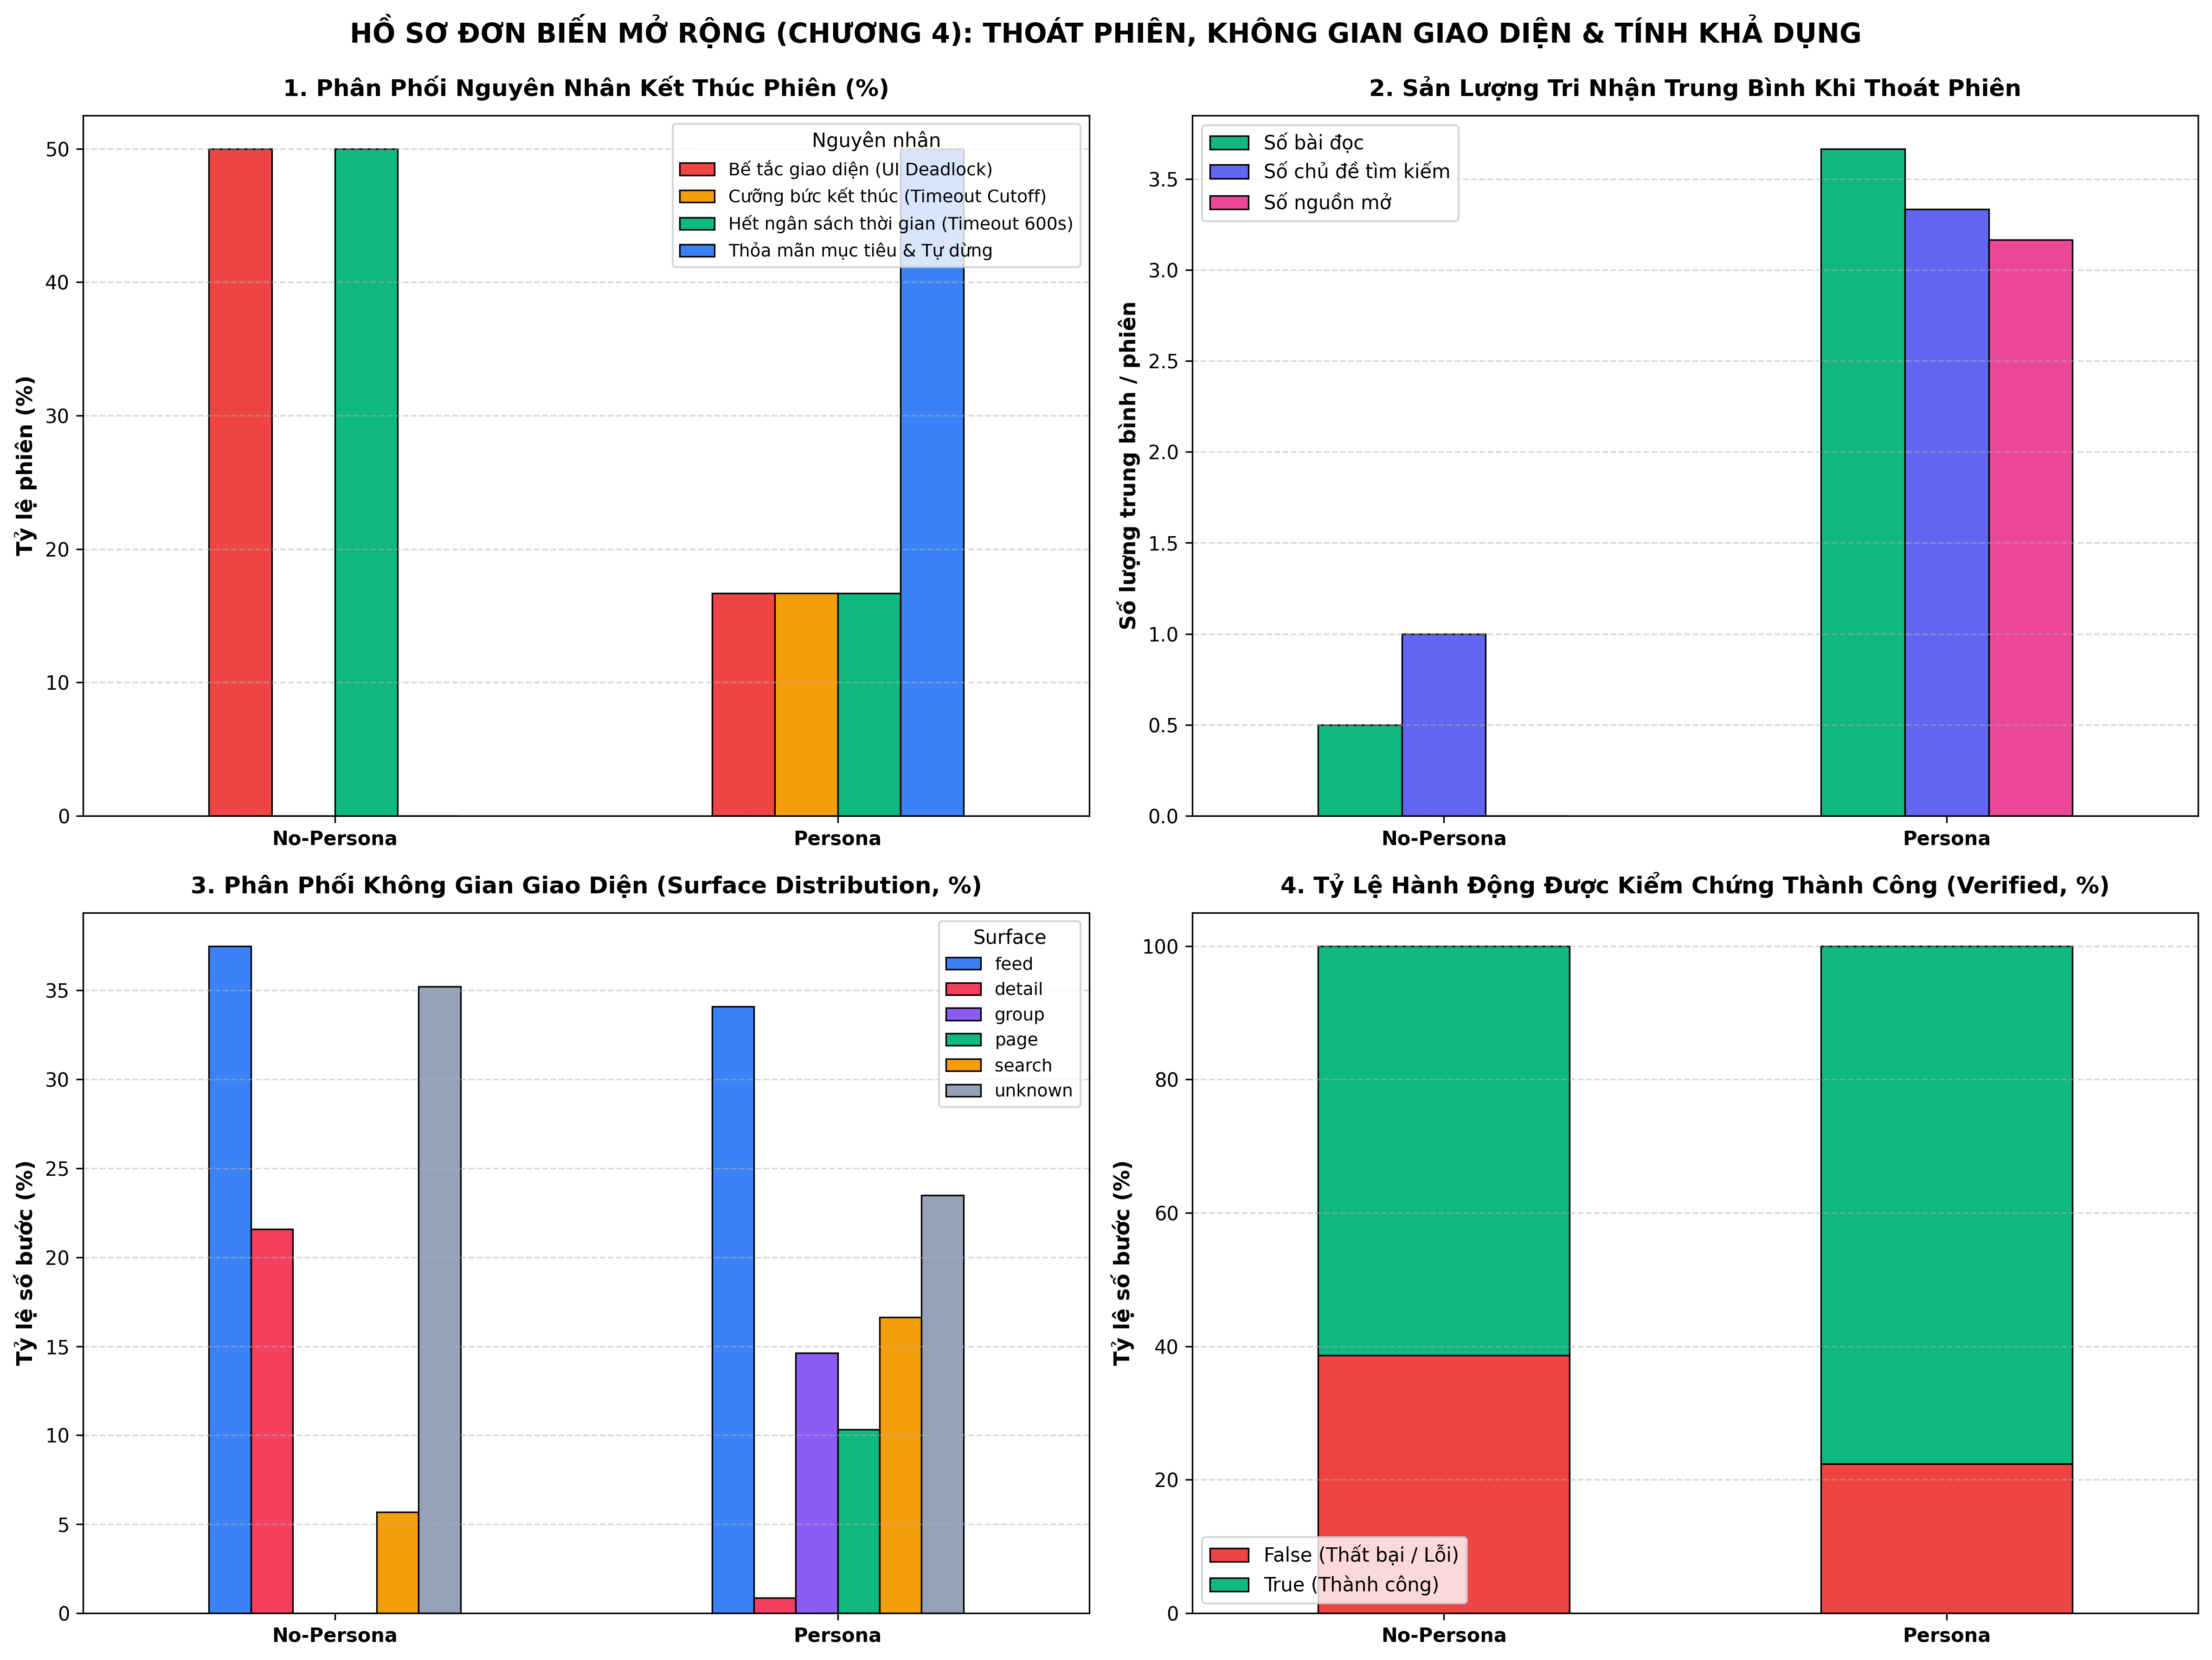

In [ ]:
# 4.3. Xuất Bảng Hồ sơ Thoát Phiên & Trực quan hóa Hồ sơ Cấp Phiên
df_term_profile = pd.read_csv(project_root / "output" / "tables" / "step4_termination_profile.csv")

print("=== BẢNG HỒ SƠ THOÁT PHIÊN CẤP PHIÊN (SESSION TERMINATION PROFILE) ===")
cols_term_show = ["group", "file_name", "total_steps", "elapsed_seconds", "overtime_seconds", "end_tool", "termination_cause"]
display(df_term_profile[cols_term_show].style.set_properties(**{'text-align': 'left'}))

# Hiển thị biểu đồ 2 ô cấp phiên (Nguyên nhân Thoát phiên & Nhịp độ Thời gian Step Delta)
display(Image(filename=str(project_root / "output" / "figures" / "step4_univariate_termination_and_surfaces.png")))


## 4.4. Phân tích NLP Tiếng Việt (underthesea) & So Sánh Phân Phối Token Bằng Log-Odds Ratio

Để đào sâu vào **suy nghĩ nhận thức (Chain-of-Thought - `reason`)** của Agent và tìm ra các từ ngữ đặc trưng phân hóa tư duy giữa 2 nhóm, chúng tôi xây dựng pipeline xử lý ngôn ngữ tự nhiên tiếng Việt:
1. **Tách từ ghép tiếng Việt (Vietnamese Word Segmentation):** Sử dụng thư viện chuyên dụng `underthesea` (`word_tokenize`) để nhận diện chính xác các khái niệm đa âm tiết (`bài_viết`, `sở_thích`, `khám_phá`, `tương_tác`, `bình_luận`, `thông_tin`, `nội_dung`...).
2. **Lọc Stopwords tên miền mạng xã hội:** Loại bỏ các từ dừng giao diện (`page`, `group`, `mở`, `home`, `sở_thích`, `khám_phá`, `có`, `like`, `react`, `bài`, `xem`...).
3. **Tính toán Phân phối Xác suất Token:**
   $$P_P(w) = \frac{\text{count}_P(w)}{\sum_v \text{count}_P(v)}, \quad P_N(w) = \frac{\text{count}_N(w)}{\sum_v \text{count}_N(v)}$$
4. **Tính toán Log-Odds Ratio $LR(w)$:**
   $$LR(w) = \log\frac{P_P(w) + \epsilon}{P_N(w) + \epsilon}$$
   - $LR(w) > 0$: Từ ngữ phản ánh bản sắc độc bản của Persona (`cờ_vua`, `thiền`, `cộng_đồng`, `phù_hợp`, `nhiếp_ảnh`, `yoga`, `đạp_xe`...).
   - $LR(w) < 0$: Từ ngữ phản ánh suy luận thụ động, cơ học của No-Persona (`kết_quả`, `tìm_kiếm`, `quay_lại`, `lướt`, `chi_tiết`, `truy_vấn`...).

[✓] Đã lưu biểu đồ log-ratio tại: D:\source_code\eda_persona\output\figures\step4_underthesea_log_ratio.png
=== TOP TOKEN PHÂN HÓA SUY NGHĨ NHẬN THỨC (LOG-ODDS RATIO VỚI UNDERTHESEA) ===


,token,count_persona,count_nopersona,total_count,prob_persona,prob_nopersona,log_ratio,log2_ratio,orientation
0,nội_dung,63,0,63,0.0273,0.0000,+7.91,11.417500,Thiên về Persona (LR > +1.0)
1,việt_nam,50,0,50,0.0217,0.0000,+7.68,11.084200,Thiên về Persona (LR > +1.0)
2,cờ,44,0,44,0.0191,0.0000,+7.56,10.899900,Thiên về Persona (LR > +1.0)
3,vua,43,0,43,0.0187,0.0000,+7.53,10.866800,Thiên về Persona (LR > +1.0)
4,phù_hợp,33,0,33,0.0143,0.0000,+7.27,10.485100,Thiên về Persona (LR > +1.0)
5,cờ_vua,30,0,30,0.0130,0.0000,+7.17,10.347700,Thiên về Persona (LR > +1.0)
6,lịch_sử,28,0,28,0.0122,0.0000,+7.10,10.248300,Thiên về Persona (LR > +1.0)
7,phong_cảnh,25,0,25,0.0109,0.0000,+6.99,10.084900,Thiên về Persona (LR > +1.0)
8,nhiếp_ảnh,23,0,23,0.0100,0.0000,+6.91,9.964700,Thiên về Persona (LR > +1.0)
9,thể_thao,20,0,20,0.0087,0.0000,+6.77,9.763300,Thiên về Persona (LR > +1.0)


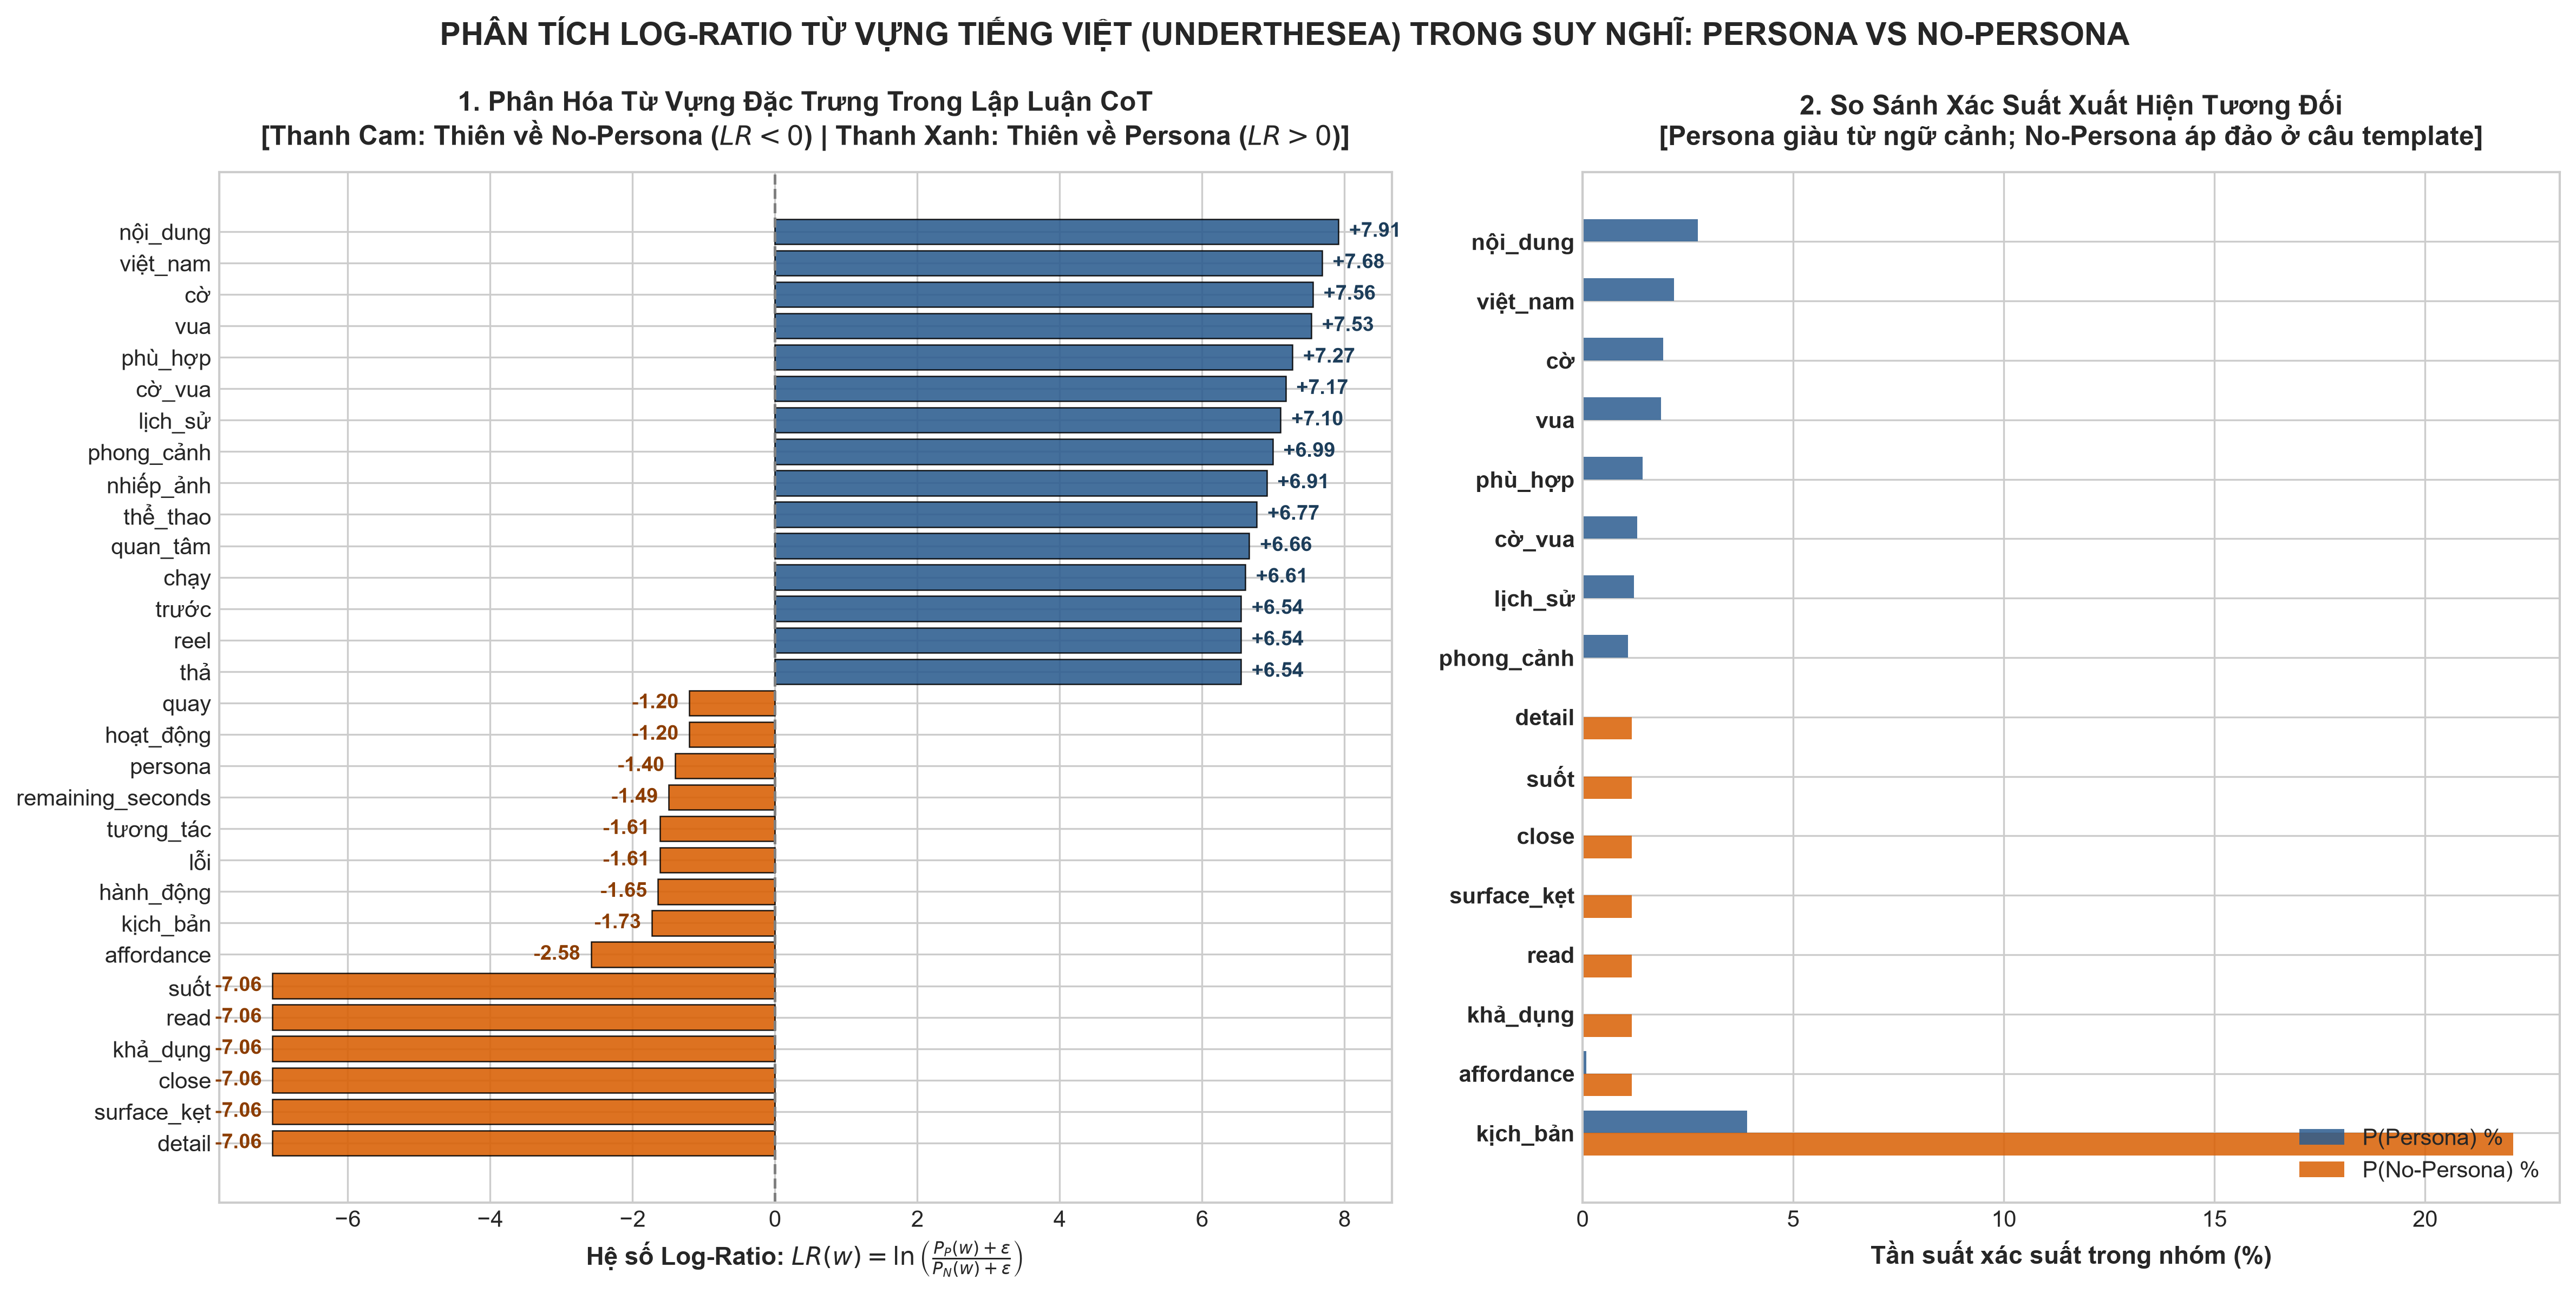

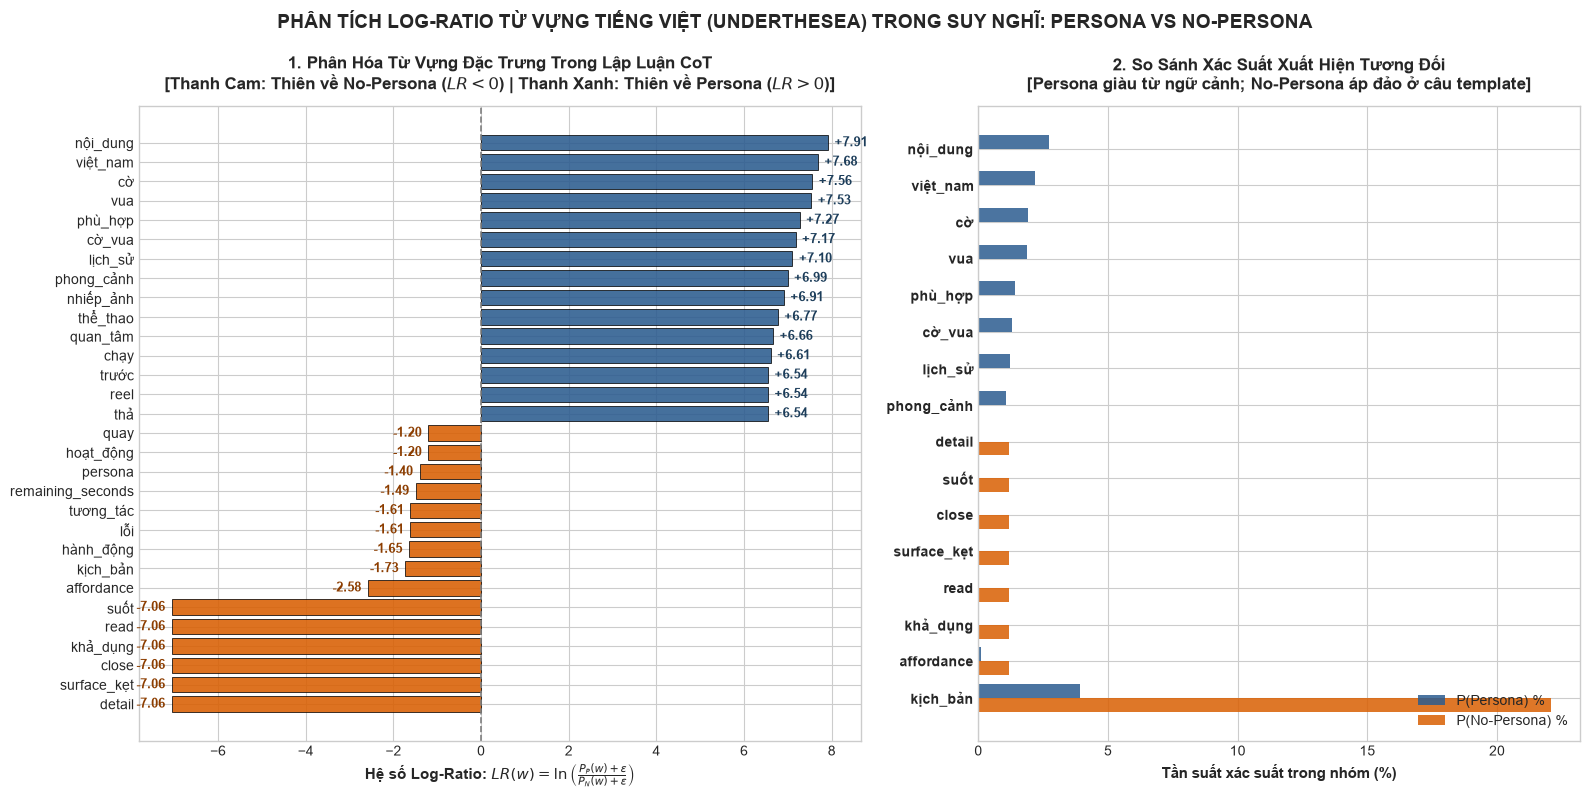

In [ ]:
# 4.4. Pipeline underthesea tokenization & Log-Ratio Distribution Comparison
from algorithms.underthesea_log_ratio_profiler import compute_underthesea_log_ratio
from viz.underthesea_viz import plot_underthesea_log_ratio_divergence

# 1. Thực thi tách từ underthesea và tính toán Log-ratio
log_ratio_res = compute_underthesea_log_ratio(
    df_steps,
    text_col="reason",
    group_col="dataset_type",
    min_count=2,
    filter_stopwords=True
)

df_lr = log_ratio_res["log_ratio_table"]
df_lr.to_csv(project_root / "output" / "tables" / "step4_underthesea_log_ratio.csv", index=False, encoding="utf-8-sig")

# 2. Vẽ biểu đồ phân cực Log-Ratio
plot_underthesea_log_ratio_divergence(
    log_ratio_res,
    top_k=15,
    output_path=project_root / "output" / "figures" / "step4_underthesea_log_ratio.png"
)

print("=== TOP TOKEN PHÂN HÓA SUY NGHĨ NHẬN THỨC (LOG-ODDS RATIO VỚI UNDERTHESEA) ===")
display(df_lr.head(15).style.set_properties(**{'text-align': 'right'}).format({
    'prob_persona': '{:.4f}', 'prob_nopersona': '{:.4f}', 'log_ratio': '{:+.2f}'
}))

# Hiển thị biểu đồ phân kỳ từ vựng NLP
display(Image(filename=str(project_root / "output" / "figures" / "step4_underthesea_log_ratio.png")))

## 4.5. Tổng hợp Tín hiệu Đơn biến Gợi mở cho 4 Giả thuyết Thực nghiệm ($H_1 \rightarrow H_4$)

Toàn bộ các phát hiện phân phối đơn biến (Định lượng nhận thức + Cơ chế Guardrail + Không gian Surface + Hồ sơ Thoát phiên + NLP) đã hội tụ và tạo tiền đề vững chắc cho việc kiểm định thống kê chính thức ở Bước 5:

In [ ]:
# 4.5. Đọc và hiển thị Bảng Ánh xạ Tín hiệu Sơ khởi Toàn diện cho 4 Giả thuyết
df_hypo_signals = pd.read_csv(project_root / "output" / "tables" / "step4_hypotheses_preliminary_signals.csv")
display(df_hypo_signals.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'font-size': '12px'
}))


,Giả thuyết,Nhóm biến số cốt lõi,Tín hiệu Đơn biến Khảo sát,Gợi ý Hướng Kiểm định
0,H1: Định hướng tìm kiếm nội dung (Target Selection),"has_target_candidate, target_candidate_kind, intent, wm_cumulative_reads","Persona thực hiện 80 lượt đọc/tương tác sâu (read: 14.6%, react: 8.6%) và mở 2-4 nguồn thực thể Page/Group; No-Persona chỉ đọc 1 bài (0.5 bài/phiên) và 0 trang mở.",Phân phối mục tiêu phân hóa rõ rệt. Cần kiểm định Chi-square & Delta-P ở Bước 5 để đo lường xác suất click và tương tác đúng nội dung quan tâm của Persona so với Baseline.
1,H2: Thao tác cuộn chuột và nhịp độ tương tác (Biomechanical Pacing),"recent_last_gesture_px, recent_last_gesture_ms, gesture_pace, step_delta_sec","Persona duy trì 104 thao tác cuộn chuẩn con người (Trung vị = 463px, nhịp 8.91s); No-Persona cuộn tuột quá đà 684–1200px chỉ 7 lần (nhịp giật cục 4.07s hoặc đơ 24-63s).","Sự khác biệt về biên độ cuộn đạt ý nghĩa thống kê (Mann-Whitney U, p = 0.0135). Cần kiểm định phân phối cự ly thời gian (Inter-action latency) và nhịp độ cuộn ở Bước 5."
2,H3: Khả năng tập trung và tránh phân tâm (Anti-Drift & Guardrail),"wm_has_novelty_warning, wm_situational_steps, warning_steps_count","Persona đạt tỷ lệ cảnh báo 0.0% (0/349 bước, max sa đà = 0); No-Persona bị cảnh báo nhắc nhở 30.68% số bước (27/88 bước, max sa đà = 6 bước, p < 0.0001).","Persona tự duy trì mục tiêu mà không cần nhắc nhở, trong khi No-Persona thường xuyên bị phân tâm. Cần kiểm định tỷ lệ cảnh báo ở Bước 5."
3,H4: Ký ức dài hạn và quản lý thời gian phiên (Memory & Session Management),"termination_cause, reads_at_exit, searches_at_exit, opened_at_exit, recent_queries_from_memory","Persona có 50% số phiên tự dừng chủ động khi thỏa mãn mục tiêu (đọc 3.67 bài, search 3.33 chủ đề); No-Persona 100% kết thúc do bế tắc UI Deadlock (50%) hoặc Timeout 600s.",Chỉ số hoàn thành và năng suất thu nhận của Persona cao vượt trội. Cần kiểm định tương quan giữa việc sử dụng ký ức với mức độ chủ động kết thúc phiên ở Bước 5.
